In [1]:
from staticnet_invariance.segmentation import *
from staticnet_invariance import toy_deis,toy
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

from numpy.fft import fft2, fftshift, fftfreq
import scipy.stats as stats
import seaborn as sns

/usr/local/lib/python3.8/dist-packages/skimage/io/manage_plugins.py:23: UserWarning: Your installed pillow version is < 8.1.2. Several security issues (CVE-2021-27921, CVE-2021-25290, CVE-2021-25291, CVE-2021-25293, and more) have been fixed in pillow 8.1.2 or higher. We recommend to upgrade this library.
  from .collection import imread_collection_wrapper


Connecting zhiwei@at-database.stanford.edu:3306


/src/static-networks/staticnet_analyses/multi_mei.py:1648: UserWarning: Use of this table is deprecated. It is kept only for record keeping purpose
  warnings.warn('Use of this table is deprecated. It is kept only for record keeping purpose')


You should consider upgrading via the '/usr/local/bin/python -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
from staticnet_pilots import analyses

def df_to_sql(df, table_name):
    cols = ", ".join([f'"{c}" TEXT' for c in df.columns])
    create_stmt = f"CREATE TABLE {table_name} ({cols});\n"

    insert_stmts = ""
    for _, row in df.iterrows():
        values = ", ".join([f"'{str(v)}'" for v in row.values])
        insert_stmts += f"INSERT INTO {table_name} VALUES ({values});\n"

    return create_stmt + insert_stmts

export_table = (MostExcitingCrop  & 'most_exciting_crop_params=5 and dataset_params=1 and mei_params = 10 and mask_params = 3' & (deis_schema.NeuronSetRequest & 'method_id = 3'))
MostExcitingCropTable = pd.DataFrame(export_table.fetch())

sql_crop = df_to_sql(MostExcitingCropTable, "MostExcitingCrop")

with open("MostExcitingCrop.sql", "w") as f:
    f.write(sql_crop)


# Helper methods

In [3]:
# This is the one with replacement
def get_dataloader_v2(search_params):
    from torch.utils.data import DataLoader, RandomSampler
    g = torch.Generator()
    g.manual_seed(search_params['search_seed'])
    
    img_path = '/./src/static-networks/CUB/CUB_200_2011'
    img_transform = transforms.Compose([transforms.Resize((search_params['transform_height'],search_params['transform_width'])),
                                     transforms.Grayscale(num_output_channels=1),
                                     transforms.ToTensor()])
    mask_transform = transforms.Compose([transforms.Resize((search_params['transform_height'],search_params['transform_width'])),
                                         transforms.Grayscale(num_output_channels=1),transforms.ToTensor()])
    label_path = '/./src/static-networks/CUB/segmentations'
    all_data = Cub2011(img_path = img_path,label_path = label_path,img_transform = img_transform,mask_transform=mask_transform,train=False,download=False)
    sampler = RandomSampler(data_source=all_data,replacement=True,num_samples=32,generator=g)
    
    all_dl = DataLoader(all_data, batch_size=32, drop_last=False)
    return all_dl
def process_crop(crops,params,key,crop_subfield_mask,keep_subfield_mask):
    mask_float, mask_x, mask_y = (base.MEIMask & key).fetch1('mask', 'mask_x', 'mask_y')
    mei_params = (base.MEIParameters & key).fetch1()
    mei = (base.MEI & key).fetch1('mei')
    crops = ops.create_whole_mei(crops, mask_float, mask_x, mask_y, (len(crops), 36, 64), normalize_crop = False)

    img = mei * crop_subfield_mask
    target_mean, target_std = img.mean(), img.std()
    crop_imgs = ops.standardize_image(crops, target_mean, target_std, crop_subfield_mask,params['mask_mean_subtraction'],params['mask_image'],params['match_stats'])
    
    imgs = crop_imgs + (mei * keep_subfield_mask)[None,:,:]
    target_mean, target_std = float(mei_params['mean']), float(mei_params['contrast'])
    imgs = ops.standardize_image(imgs, target_mean, target_std, mask_float,params['mask_mean_subtraction'],
                                   params['mask_image'],params['match_stats'])
    return imgs, crop_imgs

from numpy.fft import fft2, fftshift, fftfreq
def cal_power_spectrum(img):
    img = (img - img.mean()) / img.std()
    amp = np.abs(fft2(img))
    return fftshift(amp)
def cal_radial(power_spectrum,bins=None,cut_off=0.5):
    dist,power = [],[]
    h, w = power_spectrum.shape
    center_h, center_w = h/2, w/2
    for i in range(h):
        for j in range(w):
            temp_dist = np.sqrt((i - center_h)**2 + (j - center_w)**2)
            if temp_dist<=min(power_spectrum.shape):
                dist.append(temp_dist)
                power.append(power_spectrum[i,j])
    dist = np.array(dist)
    power = np.array(power)
    if bins is None:
        bins = min(power_spectrum.shape)
    avg, edges, _ = stats.binned_statistic(dist, power, bins=bins)
    
    coords = (edges[:-1] + edges[1:])/2
    x = np.linspace(coords[0],coords[-1],10000)
    power_predicted = np.interp(x,coords,avg)
    freq_reported = x[np.argmin(abs(np.cumsum(power_predicted)-power_predicted.sum()*cut_off))]
    return coords, avg, freq_reported

def convert_score_helper(x):
    return (x + 1)/2 

def get_random_crop_label(key,n_crop=100):
    most_exciting_crop_params = (MostExcitingCropParameters() & key).fetch1()
    dataset_params = (DatasetParameters & key).fetch1()
    all_dl = get_dataloader({**most_exciting_crop_params,**dataset_params})
    #all_dl.dataset.data = all_dl.dataset.data.sample(n=10000)
    all_dl.dataset.data = all_dl.dataset.data.sample(n=11788)
    iterator = iter(all_dl)
    
    crop_labels = []
    while True:
        try:
            images,masks = iterator.next()
            if (len(images) == 0)  or (len(masks)==0):
                break
        except:
            break
        images, masks = images.detach().cpu().numpy().squeeze(), masks.detach().cpu().numpy().squeeze()
        # Assume here that all images have the same size for convenience
        crop_results = crop_img_v2(images,masks,np.arange(len(images)),most_exciting_crop_params)
        crop_labels = crop_labels + list(crop_results['mask'])
    crop_labels = np.stack(crop_labels)
    np.random.shuffle(crop_labels)
    return crop_labels[:n_crop]

# Label mask has 1 for bird, -1 for background
def cal_match_one_number_v2(variable_mask, mei_mask, label_mask):
    object_only_mask = np.array(label_mask)
    object_only_mask[object_only_mask<0] = 0.0
    
    background_only_mask = np.array(label_mask) * -1.0
    background_only_mask[background_only_mask<0] = 0.0
    
    fixed_mask = mei_mask-variable_mask
    fixed_mask = np.clip(fixed_mask,a_min=0.0,a_max=1.0)
    
    return ((variable_mask * object_only_mask).sum() + (fixed_mask * background_only_mask).sum()) / (mei_mask.sum()+1e-9)

In [4]:
THRESHOLD = 0.2
def fig_5b_for_random(random_crop_labels):
    keys = (MostExcitingCrop  & 'most_exciting_crop_params=5 and dataset_params=1 and mei_params = 10 and mask_params = 3' &
            (deis_schema.NeuronSetRequest & 'method_id = 3')).fetch('KEY',order_by='group_id,neuron_id')


    meis,acts,object_sizes,imgs,labels,img_categories = [],[],[],[],[],[]
    for key in tqdm(keys):
        mei,mask_float,mask_x,mask_y,mei_act = (base.MEI * base.MEIMask & key).fetch1('mei','mask','mask_x','mask_y','activation')
        #meis.append(mei)
        

        #img,crop_label,act = (MostExcitingCrop & key).fetch1('crop_masked','crop_label','act')
        crop_label = random_crop_labels
        #act = act/mei_act
        full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)

        masked_crop_label = full_crop_label * mask_float[None,:,:]
        size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
        # Patch that contain object boundary
        idx = np.logical_and(size>THRESHOLD,size<(1-THRESHOLD))
        img_categories.append(idx)
    return img_categories

# Goal is to reproduce Fig 5b
def fig_5b_for_real():
    keys = (MostExcitingCrop  & 'most_exciting_crop_params=5 and dataset_params=1 and mei_params = 10 and mask_params = 3' &
            (deis_schema.NeuronSetRequest & 'method_id = 3')).fetch('KEY',order_by='group_id,neuron_id')


    meis,acts,object_sizes,imgs,labels,img_categories = [],[],[],[],[],[]
    for key in tqdm(keys):
        mei,mask_float,mask_x,mask_y,mei_act = (base.MEI * base.MEIMask & key).fetch1('mei','mask','mask_x','mask_y','activation')
        meis.append(mei)
        

        img,crop_label,act = (MostExcitingCrop & key).fetch1('crop_masked','crop_label','act')
        #act = act/mei_act
        full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)

        masked_crop_label = full_crop_label * mask_float[None,:,:]
        size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
        # Patch that contain object boundary
        idx = np.logical_and(size>THRESHOLD,size<(1-THRESHOLD))
        img_categories.append(idx)
    return img_categories

def fig_5c_for_real(valid_crop=False):
    keys = (MostExcitingCrop  & 'most_exciting_crop_params=5 and dataset_params=1 and mei_params = 10 and mask_params = 3' &
            (deis_schema.NeuronSetRequest & 'method_id = 3')).fetch('KEY',order_by='group_id,neuron_id')


    matching_scores = []
    for key in tqdm(keys):
        
        if key['group_id']<=237:
            rest = {'diverse_params': 14, 'texture_params':20,'score_params':2}
        else: 
            rest= {'diverse_params':17,'texture_params':20,'score_params':2}

        mei,mask_float,mask_x,mask_y,mei_act = (base.MEI * base.MEIMask & key).fetch1('mei','mask','mask_x','mask_y','activation')
        
        v_mask = (deis_schema.Texture * deis_schema.TextureGoodRun & key & rest).fetch1('variable_mask')
        img,crop_label,act = (MostExcitingCrop & key).fetch1('crop_masked','crop_label','act')
        #act = act/mei_act
        full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)
        
        if valid_crop:
            masked_crop_label = full_crop_label * mask_float[None,:,:]
            size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
            idx = np.where(np.logical_and(size>THRESHOLD,size<(1-THRESHOLD)))[0]
            print(len(idx))
            if len(idx)<1:
                print(key)
                assert len(idx)<1
            full_crop_label = full_crop_label[idx]     
            
        matching_scores.append(np.array([cal_match_one_number_v2(v_mask,mask_float,i) for i in full_crop_label]))
    return matching_scores

def fig_5c_for_random(valid_crop=False):
    keys = (MostExcitingCrop  & 'most_exciting_crop_params=5 and dataset_params=1 and mei_params = 10 and mask_params = 3' &
            (deis_schema.NeuronSetRequest & 'method_id = 3')).fetch('KEY',order_by='group_id,neuron_id')


    matching_scores = []
    for key in tqdm(keys):
        
        if key['group_id']<=237:
            rest = {'diverse_params': 14, 'texture_params':20,'score_params':2}
        else: 
            rest= {'diverse_params':17,'texture_params':20,'score_params':2}

        mei,mask_float,mask_x,mask_y,mei_act = (base.MEI * base.MEIMask & key).fetch1('mei','mask','mask_x','mask_y','activation')
        
        v_mask = (deis_schema.Texture * deis_schema.TextureGoodRun & key & rest).fetch1('variable_mask')
        #img,crop_label,act = (MostExcitingCrop & key).fetch1('crop_masked','crop_label','act')
        crop_label = random_crop_labels
        #act = act/mei_act
        full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)
        
        if valid_crop:
            masked_crop_label = full_crop_label * mask_float[None,:,:]
            size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
            idx = np.where(np.logical_and(size>THRESHOLD,size<(1-THRESHOLD)))[0]
            print(len(idx))
            if len(idx)<1:
                print(key)
                assert len(idx)<1
            full_crop_label = full_crop_label[idx]     
            
        matching_scores.append(np.array([cal_match_one_number_v2(v_mask,mask_float,i) for i in full_crop_label]))
    return matching_scores

def fig_5b_result_helper(rest):
    all_simulated_keys = (toy.GroupAssignment.Member * toy_deis.MEIMask & rest).fetch('KEY',order_by='neuron_type,member_id')
    all_simulated_keys = all_simulated_keys

    meis,acts,object_sizes,imgs,labels,img_categories = [],[],[],[],[],[]
    additional_rest = {'dataset_params':1,'most_exciting_crop_params':5}
    for key in tqdm(all_simulated_keys):
        mei_act = (toy_deis.MEI & key & 'mei_params = 1').fetch1('activation')

        mei,mask_float,mask_x,mask_y = (toy_deis.MEI * toy_deis.MEIMask & key & 'mei_params = 1 and mask_params = 3').fetch1('mei','mask','mask_x','mask_y')
        meis.append(mei)
        

        img,crop_label,act = (ToyMostExcitingCrop & 'mei_params = 1 and mask_params = 3' & key & additional_rest).fetch1('crop_masked','crop_label','act')
        #act = act/mei_act
        full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)

        masked_crop_label = full_crop_label * mask_float[None,:,:]
        size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
        # Patch that contain object boundary
        idx = np.logical_and(size>0.2,size<0.8)
        img_categories.append(idx)
    return img_categories

def fig_5f_for_real():
    rest = {'mei_params':10,'mask_params':3}
    keys = (deis_schema.NeuronSetRequest & 'method_id = 3').fetch('KEY',order_by='group_id,neuron_id')
    
    dataset_params_dict = {16:'same_freq\ndiff ori',17:'same_freq\ndiff ori',18:'diff_freq\ndiff ori',19:'diff_freq\ndiff ori',
                           20:'single_grating',21:'single_grating',24:'same_ori\ndiff freq',25:'same_ori\ndiff freq'}
    most_exciting_crop_param_dict = {16:8,17:8,18:8,19:8,20:5,21:5,24:8,25:8}   

    meis,acts,object_sizes,imgs,labels,img_categories = [],[],[],[],[],[]

    for key in tqdm(keys):
        mei,mask_float,mask_x,mask_y,mei_act = (base.MEI * base.MEIMask & key & rest).fetch1('mei','mask','mask_x','mask_y','activation')
        meis.append(mei)
        temp_act,temp_object_size,temp_img,temp_label,temp_img_category = [],[],[],[],[]
        for i in dataset_params_dict.keys():
            additional_rest = {'dataset_params':i,'most_exciting_crop_params':most_exciting_crop_param_dict[i]}
            img,crop_label,act = (MostExcitingCrop & key & additional_rest & rest).fetch1('crop_masked','crop_label','act')
            act = act/mei_act
            full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)

            masked_crop_label = full_crop_label * mask_float[None,:,:]
            size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
            if dataset_params_dict[i] != 'single_grating':
                idx = np.where(np.logical_and(size>THRESHOLD,size<(1-THRESHOLD)))[0]
                
            else:
                idx = np.arange(len(size))
            if len(idx)>0:
                temp_act.append(act[idx])
                temp_object_size.append(size[idx])
                temp_img.append(img[idx])
                temp_label.append(masked_crop_label[idx])
                temp_img_category.append(np.full(act[idx].shape,dataset_params_dict[i]))
        max_idx = np.argmax(np.concatenate(temp_act))
        acts.append(np.concatenate(temp_act)[max_idx])
        object_sizes.append(np.concatenate(temp_object_size)[max_idx])
        imgs.append(np.concatenate(temp_img)[max_idx])
        labels.append(np.concatenate(temp_label)[max_idx])
        img_categories.append(np.concatenate(temp_img_category)[max_idx])
    return  meis,acts,object_sizes,imgs,labels,img_categories

def fig_5f_result_helper(rest,new_condition=True):

    all_simulated_keys = (toy.GroupAssignment.Member * toy_deis.MEIMask & rest).fetch('KEY',order_by='neuron_type,member_id')
    all_simulated_keys = all_simulated_keys
    if not new_condition:
        dataset_params_dict = {16:'same_freq\ndiff ori',17:'same_freq\ndiff ori',18:'diff_freq\ndiff ori',19:'diff_freq\ndiff ori',
                               20:'single_grating',21:'single_grating',24:'same_ori\ndiff freq',25:'same_ori\ndiff freq'}
        most_exciting_crop_param_dict = {16:8,17:8,18:8,19:8,20:5,21:5,24:8,25:8}   
    else:
        dataset_params_dict = {26:'same_freq\ndiff ori',27:'same_freq\ndiff ori',28:'diff_freq\ndiff ori',29:'diff_freq\ndiff ori',
                               30:'single_grating',31:'single_grating',34:'same_ori\ndiff freq',35:'same_ori\ndiff freq'}
        most_exciting_crop_param_dict = {26:8,27:8,28:8,29:8,30:5,31:5,34:8,35:8}   
    # else:
    #     dataset_params_dict = {36:'same_freq\ndiff ori',37:'same_freq\ndiff ori',38:'diff_freq\ndiff ori',39:'diff_freq\ndiff ori',
    #                            40:'single_grating',41:'single_grating',44:'same_ori\ndiff freq',45:'same_ori\ndiff freq'}
    #     most_exciting_crop_param_dict = {36:8,37:8,38:8,39:8,40:5,41:5,44:8,45:8}   

    meis,acts,object_sizes,imgs,labels,img_categories = [],[],[],[],[],[]

    for key in tqdm(all_simulated_keys):
        mei,mask_float,mask_x,mask_y,mei_act = (toy_deis.MEI * toy_deis.MEIMask & key & 'mei_params = 1 and mask_params = 3').fetch1('mei','mask','mask_x','mask_y','activation')
        meis.append(mei)
        temp_act,temp_object_size,temp_img,temp_label,temp_img_category = [],[],[],[],[]
        for i in dataset_params_dict.keys():
            additional_rest = {'dataset_params':i,'most_exciting_crop_params':most_exciting_crop_param_dict[i]}
            img,crop_label,act = (ToyMostExcitingCrop & 'mei_params = 1 and mask_params = 3' & key & additional_rest).fetch1('crop_masked','crop_label','act')
            act = act/mei_act
            full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)

            masked_crop_label = full_crop_label * mask_float[None,:,:]
            size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
            if dataset_params_dict[i] != 'single_grating':
                idx = np.where(np.logical_and(size>THRESHOLD,size<(1-THRESHOLD)))[0]
            else:
                idx = np.arange(len(size))
            if len(idx)>0:
                temp_act.append(act[idx])
                temp_object_size.append(size[idx])
                temp_img.append(img[idx])
                temp_label.append(masked_crop_label[idx])
                temp_img_category.append(np.full(act[idx].shape,dataset_params_dict[i]))
        max_idx = np.argmax(np.concatenate(temp_act))
        acts.append(np.concatenate(temp_act)[max_idx])
        object_sizes.append(np.concatenate(temp_object_size)[max_idx])
        imgs.append(np.concatenate(temp_img)[max_idx])
        labels.append(np.concatenate(temp_label)[max_idx])
        img_categories.append(np.concatenate(temp_img_category)[max_idx])
    return  meis,acts,object_sizes,imgs,labels,img_categories

# 18,24 are high frequency inside
# 19, 25 are high frequency outside
def fig_5g_result_helper(fig_5f_real=None,valid_crop=True):
    matching_scores = []
    keys = (deis_schema.NeuronSetRequest & 'method_id = 3').fetch('KEY',order_by='group_id,neuron_id')
    if fig_5f_real is not None:
        fig_5f_real = np.array(fig_5f_real)
        idxs = np.where(np.logical_or((fig_5f_real == 'same_ori\ndiff freq'), (fig_5f_real == 'diff_freq\ndiff ori')))[0]
        keys = [keys[i] for i in idxs]
    for key in tqdm(keys):
        if key['group_id']<=237:
            rest = {'diverse_params': 14, 'texture_params':20,'score_params':2,'most_exciting_crop_params':8,'mei_params':10,'mask_params':3}
        else: 
            rest= {'diverse_params':17,'texture_params':20,'score_params':2,'most_exciting_crop_params':8,'mei_params':10,'mask_params':3}
            
        temp = []
        for additional_rest in ['dataset_params in (18,24)', ' dataset_params in (19,25)']:
            mei,mask_float,mask_x,mask_y,mei_act = (base.MEI * base.MEIMask & key & rest).fetch1('mei','mask','mask_x','mask_y','activation')
            v_mask = (deis_schema.Texture * deis_schema.TextureGoodRun & key & rest).fetch1('variable_mask')

            crop_label,act = (MostExcitingCrop & key & rest & additional_rest).fetch('crop_label','act',order_by='dataset_params')
            crop_label = np.concatenate(crop_label)
            act = np.concatenate(act)

            idx = np.argsort(act)
            act = act[idx]
            crop_label = crop_label[idx]

            full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)  

            if valid_crop:
                masked_crop_label = full_crop_label * mask_float[None,:,:]
                size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
                idx = np.where(np.logical_and(size>THRESHOLD,size<(1-THRESHOLD)))[0]
                print(len(idx))
                if len(idx)<1:
                    print(key)
                    assert len(idx)<1
                full_crop_label = full_crop_label[idx]   
                
            full_crop_label = full_crop_label[:100]
            temp.append(np.array([cal_match_one_number_v2(v_mask,mask_float,i) for i in full_crop_label]))
        matching_scores.append(temp)
    return matching_scores

# Version to get individual group
def fig_5f_for_real_helper():
    rest = {'mei_params':10,'mask_params':3}
    keys = (deis_schema.NeuronSetRequest & 'method_id = 3').fetch('KEY',order_by='group_id,neuron_id')
    
    dataset_params_dict = {16:'same_freq\ndiff ori',17:'same_freq\ndiff ori',18:'diff_freq\ndiff ori',19:'diff_freq\ndiff ori',
                           20:'single_grating',21:'single_grating',24:'same_ori\ndiff freq',25:'same_ori\ndiff freq'}
    most_exciting_crop_param_dict = {16:8,17:8,18:8,19:8,20:5,21:5,24:8,25:8}   

    meis,acts,object_sizes,imgs,labels,img_categories,max_act_per_group = [],[],[],[],[],[],[]

    for key in tqdm(keys):
        mei,mask_float,mask_x,mask_y,mei_act = (base.MEI * base.MEIMask & key & rest).fetch1('mei','mask','mask_x','mask_y','activation')
        meis.append(mei)
        temp_act,temp_object_size,temp_img,temp_label,temp_img_category,temp_max_act_per_group = [],[],[],[],[],[]
        for i in dataset_params_dict.keys():
            additional_rest = {'dataset_params':i,'most_exciting_crop_params':most_exciting_crop_param_dict[i]}
            img,crop_label,act = (MostExcitingCrop & key & additional_rest & rest).fetch1('crop_masked','crop_label','act')
            act = act/mei_act
            full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)

            masked_crop_label = full_crop_label * mask_float[None,:,:]
            size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
            if dataset_params_dict[i] != 'single_grating':
                idx = np.where(np.logical_and(size>THRESHOLD,size<(1-THRESHOLD)))[0]
            else:
                idx = np.arange(len(size))
            if len(idx)>0:
                temp_act.append(act[idx])
                temp_object_size.append(size[idx])
                temp_img.append(img[idx])
                temp_label.append(masked_crop_label[idx])
                temp_img_category.append(np.full(act[idx].shape,dataset_params_dict[i]))
                temp_max_act_per_group.append(act[idx].max())
            else:
                temp_max_act_per_group.append(-100)
                
        max_act_per_group.append(temp_max_act_per_group)
    return max_act_per_group
        
#         max_idx = np.argmax(np.concatenate(temp_act))
#         acts.append(np.concatenate(temp_act)[max_idx])
#         object_sizes.append(np.concatenate(temp_object_size)[max_idx])
#         imgs.append(np.concatenate(temp_img)[max_idx])
#         labels.append(np.concatenate(temp_label)[max_idx])
#         img_categories.append(np.concatenate(temp_img_category)[max_idx])
#     return  meis,acts,object_sizes,imgs,labels,img_categories

def cal_dof(x,y):
    a = x.std()**2/len(x)
    b = y.std()**2/len(y)
    return (a+b)**2 / (a**2/(len(x)-1) + b**2/(len(y)-1))

def fig_5c_for_real_flipped(valid_crop=False):
    keys = (MostExcitingCrop  & 'most_exciting_crop_params=5 and dataset_params=1 and mei_params = 10 and mask_params = 3' &
            (deis_schema.NeuronSetRequest & 'method_id = 3')).fetch('KEY',order_by='group_id,neuron_id')


    matching_scores = []
    for key in tqdm(keys):
        
        if key['group_id']<=237:
            rest = {'diverse_params': 14, 'texture_params':20,'score_params':2}
        else: 
            rest= {'diverse_params':17,'texture_params':20,'score_params':2}

        mei,mask_float,mask_x,mask_y,mei_act = (base.MEI * base.MEIMask & key).fetch1('mei','mask','mask_x','mask_y','activation')
        
        v_mask = (deis_schema.Texture * deis_schema.TextureGoodRun & key & rest).fetch1('variable_mask')
        v_mask = find_symmetrical_mask(v_mask,mask_float)

        img,crop_label,act = (MostExcitingCrop & key).fetch1('crop_masked','crop_label','act')
        #act = act/mei_act
        full_crop_label = deis_schema.create_whole_mei(crop_label, mask_float, mask_x, mask_y,(len(crop_label),36, 64),normalize_crop = False)
        
        if valid_crop:
            masked_crop_label = full_crop_label * mask_float[None,:,:]
            size = np.array([j[j>0].sum()/(mask_float.sum()+1e-9) for j in masked_crop_label])
            idx = np.where(np.logical_and(size>THRESHOLD,size<(1-THRESHOLD)))[0]
            print(len(idx))
            if len(idx)<1:
                print(key)
                assert len(idx)<1
            full_crop_label = full_crop_label[idx]     
            
        matching_scores.append(np.array([cal_match_one_number_v2(v_mask,mask_float,i) for i in full_crop_label]))
    return matching_scores

# 5b

In [4]:
rest1 = {'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2, 'texture_params': 25,  'score_params': 2}
rest2 = {'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 14, 'threshold_params': 2, 'texture_params': 25,  'score_params': 2}
keys = (deis_schema.Texture * deis_schema.TextureGoodRun & (deis_schema.NeuronSetRequest & 'method_id = 3') & rest1 & 'group_id>237').fetch('KEY')
deis_schema.TextureLookup & keys
#deis_schema.Texture * deis_schema.TextureGoodRun & (deis_schema.NeuronSetRequest & 'method_id = 3') & rest2 & 'group_id<=237'

# Texture.populate((NeuronSetRequest & 'method_id = 3'),rest1, 'group_id > 237', reserve_jobs=True)
# Texture.populate((NeuronSetRequest & 'method_id = 3'),rest2, 'group_id <= 237', reserve_jobs=True)
# TextureGoodRun.populate((NeuronSetRequest & 'method_id = 3'),rest1, 'group_id > 237', reserve_jobs=True)
# TextureGoodRun.populate((NeuronSetRequest & 'method_id = 3'),rest2, 'group_id <= 237', reserve_jobs=True)

synthesis_id unique identifier of the texture synthesis key,group_id index of group,net_hash unique identifier for configuration,seed random seed,data_hash unique identifier for configuration,readout_key,"neuron_id id of this cell in the dataset (starts at 0), same as index of responses",mei_params,mask_params,mask_stats_params,diverse_params,weight_id,ref_id,threshold_params,texture_params,texture_id Id of the run


In [5]:
rest = 'mei_params = 10 and mask_params = 3 and diverse_params in (14, 17) and texture_params = 20 and score_params = 2'
neuron_rel = deis_schema.NeuronSetRequest & 'method_id = 3'
all_keys = deis_schema.TextureLookup & (deis_schema.Texture * deis_schema.TextureGoodRun & rest & neuron_rel)
keys = all_keys.fetch('KEY')

In [6]:
rest1 = {'diverse_params': 14, 'texture_params':20,'score_params':2}
rest2 = {'diverse_params': 17, 'texture_params':20,'score_params':2}
keys = (deis_schema.NeuronSetRequest & 'method_id=3').fetch(as_dict=True)

In [7]:
np.random.seed(0)
random.seed(0)
# random_crop_labels = get_random_crop_label({'most_exciting_crop_params':5,'dataset_params':1},n_crop=100)
# with open('random_crop_label.pickle', 'wb') as handle:
#     pickle.dump(random_crop_labels,handle)
with open('random_crop_label.pickle', 'rb') as handle:
    random_crop_labels = pickle.load(handle)

In [8]:
simple_rest = {'group_id': 6,'neuron_type':"Simple", 'config_id':1,'mei_params': 1, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2},
complex_rest = {'group_id': 6,'neuron_type':"Complex", 'config_id':1,'mei_params': 1, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2},
         

In [8]:
fig_5b_random = fig_5b_for_random(random_crop_labels)
fig_5b_real = fig_5b_for_real()
fig_5b_simple = fig_5b_result_helper(simple_rest)
fig_5b_complex = fig_5b_result_helper(complex_rest)

# We can apply filters by 5b to take valid_crop post
fig_5c_random = fig_5c_for_random(valid_crop=False)
fig_5c_real = fig_5c_for_real(valid_crop=False)
fig_5c_flipped = fig_5c_for_real_flipped(valid_crop=False)

100%|██████████| 1200/1200 [01:31<00:00, 13.08it/s]


In [9]:
fig_5f_real = fig_5f_for_real()[-1]
fig_5f_simple = fig_5f_result_helper(simple_rest,new_condition=True)[-1]
fig_5f_complex = fig_5f_result_helper(complex_rest,new_condition=True)[-1]

100%|██████████| 60/60 [00:49<00:00,  1.20it/s]


In [ ]:
fig_5g = fig_5g_result_helper(fig_5f_real,True)

max_act_per_group = fig_5f_for_real_helper()

  3%|▎         | 32/1200 [00:08<05:28,  3.56it/s]

In [9]:
# fig_5f_real = fig_5f_for_real()

# fig_5f_simple = fig_5f_result_helper(simple_rest,new_condition=True)
# fig_5f_complex = fig_5f_result_helper(complex_rest,new_condition=True)

/usr/local/lib/python3.8/dist-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.8/dist-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


1199


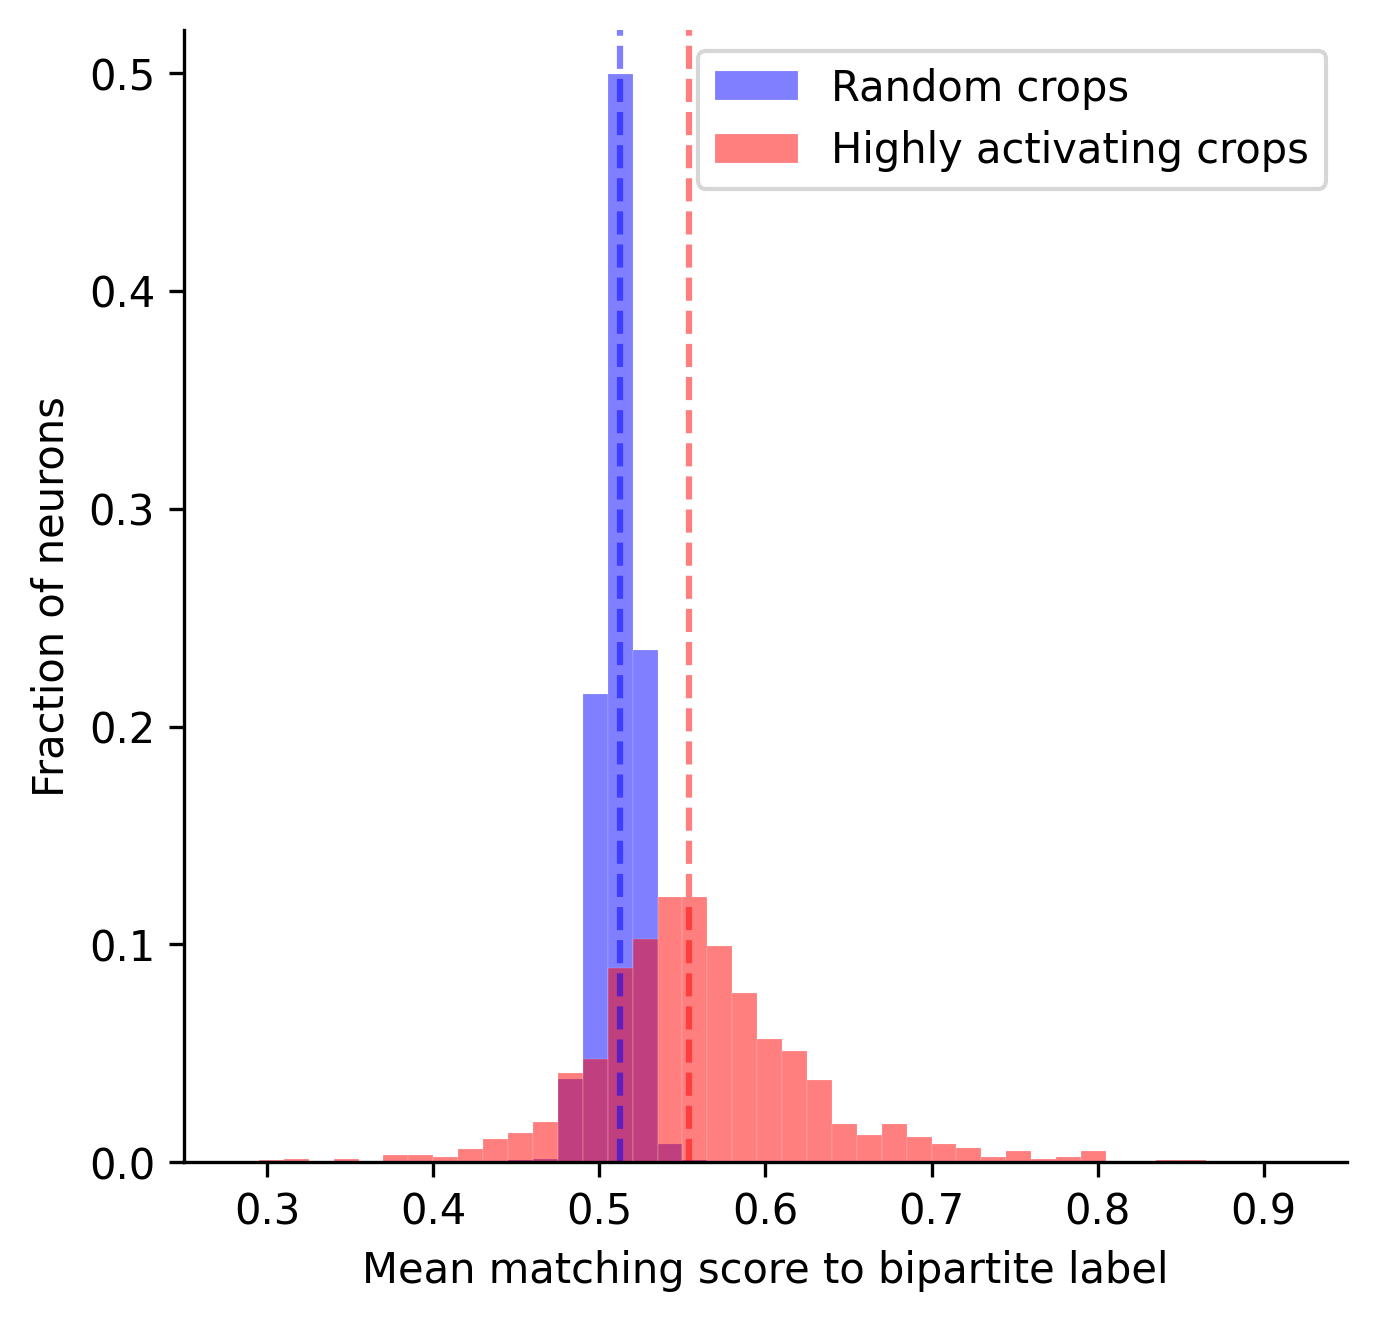

In [19]:
plt.figure(figsize=(5, 5), dpi=300)
# a = np.array([np.mean(i) for i in fig_5c_random])
# b = np.array([np.mean(i) for i in fig_5c_real])
a = np.array([np.mean(i[j]) for i,j in zip(fig_5c_random,fig_5b_random)])
b = np.array([np.mean(i[j]) for i,j in zip(fig_5c_real,fig_5b_real)])
shared_idx = ~np.logical_or(np.isnan(a),np.isnan(b))
print(shared_idx.sum())
a = a[shared_idx]
b = b[shared_idx]

sns.histplot(a,color='blue',alpha=0.5,stat='probability',kde=False,binrange=[0.25,0.92],binwidth=0.015,label='Random crops',edgecolor="white", linewidth=0.04)
sns.histplot(b,color='red',alpha=0.5,stat='probability',kde=False,binrange=[0.25,0.92],binwidth=0.015,label='Highly activating crops',edgecolor="white", linewidth=0.04)
# plt.axvline(x=np.median(b),c='red',linestyle='--',alpha=0.5)
# plt.axvline(x=np.median(a),c='blue',linestyle='--',alpha=0.5)
plt.axvline(x=np.median(b),c='red',linestyle='--',alpha=0.5)
plt.axvline(x=np.median(a),c='blue',linestyle='--',alpha=0.5)

plt.xlabel('Mean matching score to bipartite label')
plt.ylabel('Fraction of neurons')
plt.legend()
sns.despine()
plt.xticks([0.3,0.4,0.5,0.6,0.7,0.8,0.9])
plt.xlim(0.25,0.95)
plt.yticks([0,0.1,0.2,0.3,0.4,0.5])
plt.ylim(0,0.52)
#plt.savefig("fig_5c.pdf",bbox_inches='tight',transparent=True,pad_inches = 0)

In [23]:
#wilcoxon(a,b,alternative='less')
wilcoxon(a,b)

WilcoxonResult(statistic=82849.0, pvalue=6.498655303967533e-118)

In [54]:
print(wilcoxon(a,b))
a = [i[j] for i,j in zip(fig_5c_random,fig_5b_random)]
b = [i[j] for i,j in zip(fig_5c_real,fig_5b_real)]
# shared_idx = ~np.logical_or(np.isnan(a),np.isnan(b))
# print(shared_idx.sum())
# a = a[shared_idx]
# b = b[shared_idx]

In [62]:
np.nanmean([cal_dof(i,j) for i,j in zip(a,b)])

76.21670084348659

In [65]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

ps = np.array([ttest_ind(i,j,equal_var=False,alternative='less')[1] for i,j in zip(a,b)])
print((ps<0.05).sum()/len(ps))
multipletests(ps,0.05,method="fdr_bh")[0].sum()/len(ps)

0.57


0.5166666666666667

# 5d

In [5]:
keys = (PartialRandomCrop & 'random_crop_params=2').fetch('synthesis_id',as_dict=True,order_by='synthesis_id')
#ps = np.array([(deis_schema.Texture & (deis_schema.TextureLookup & i)).fetch1('p') for i in tqdm(keys)])

NameError: name 'PartialRandomCrop' is not defined

In [25]:
x,y,p1,p2 = [],[],[],[]
for i in tqdm(keys):
    a,b = (PartialRandomCrop & 'random_crop_params=2' & i).fetch1('fixed_act','fixed_median_freq')
    c,d = (PartialRandomCrop & 'random_crop_params=1' & i).fetch1('fixed_act','fixed_median_freq')
    x.append(pearsonr(a,b)[0])
    y.append(pearsonr(c,d)[0])
    p1.append(pearsonr(a,b)[1])
    p2.append(pearsonr(c,d)[1])

 16%|█▌        | 186/1200 [00:04<00:23, 43.89it/s]/usr/local/lib/python3.8/dist-packages/scipy/stats/_stats_py.py:4068: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())
 22%|██▏       | 269/1200 [00:06<00:21, 43.73it/s]/usr/local/lib/python3.8/dist-packages/scipy/stats/_stats_py.py:4068: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())
 65%|██████▌   | 784/1200 [00:18<00:09, 43.80it/s]/usr/local/lib/python3.8/dist-packages/scipy/stats/_stats_py.py:4068: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())
 80%|███████▉  | 954/1200 [00:21<00:05, 45.29it/s]/usr/local/lib/python3.8/dist-packages/scipy/stats/_stats_py.py:4068: PearsonRConstantInputWarning: An input array is constant; the correlat

In [574]:
a,b,c,d = (PartialRandomCrop & 'random_crop_params=2').fetch('fixed_act','var_act','fixed_median_freq','var_median_freq',order_by='synthesis_id')

In [575]:
rs1,ps1 = [],[]
for i,j in zip(a,c):
    r,p = pearsonr(i,j)
    if np.isnan(p):
        p = 1.0
    rs1.append(r)
    ps1.append(p)
rs1 = np.array(rs1)
ps1 = np.array(ps1)

/root/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [576]:
(ps1<=0.05).sum()

1090

In [577]:
rs2,ps2 = [],[]
for i,j in tqdm(zip(b,d)):
    r,p = pearsonr(i,j)
    if np.isnan(p):
        p = 1.0
    rs2.append(r)
    ps2.append(p)
rs2 = np.array(rs2)
ps2 = np.array(ps2)

1200it [00:00, 1238.84it/s]


In [578]:
(ps2<=0.05).sum()

1087

In [579]:
from statsmodels.stats.multitest import multipletests
corrected_ps = multipletests(np.concatenate([ps1,ps2]),0.05,method="fdr_bh")[1]
corrected_ps1 = corrected_ps[:len(ps1)]
corrected_ps2 = corrected_ps[len(ps1):]

In [586]:
print((ps1<=0.05).sum()/len(ps1))
print((ps2<=0.05).sum()/len(ps2))
print(len(ps1<=0.05))
print(len(ps2<=0.05))

print(np.logical_and(rs1<=0,corrected_ps1<=0.05).sum()/len(corrected_ps1))
print(np.logical_and(rs2>=0,corrected_ps2<=0.05).sum()/len(corrected_ps2))
print(len(corrected_ps1<=0.05))
print(len(corrected_ps2<=0.05))

0.9083333333333333
0.9058333333333334
1200
1200
0.7908333333333334
0.6475
1200
1200


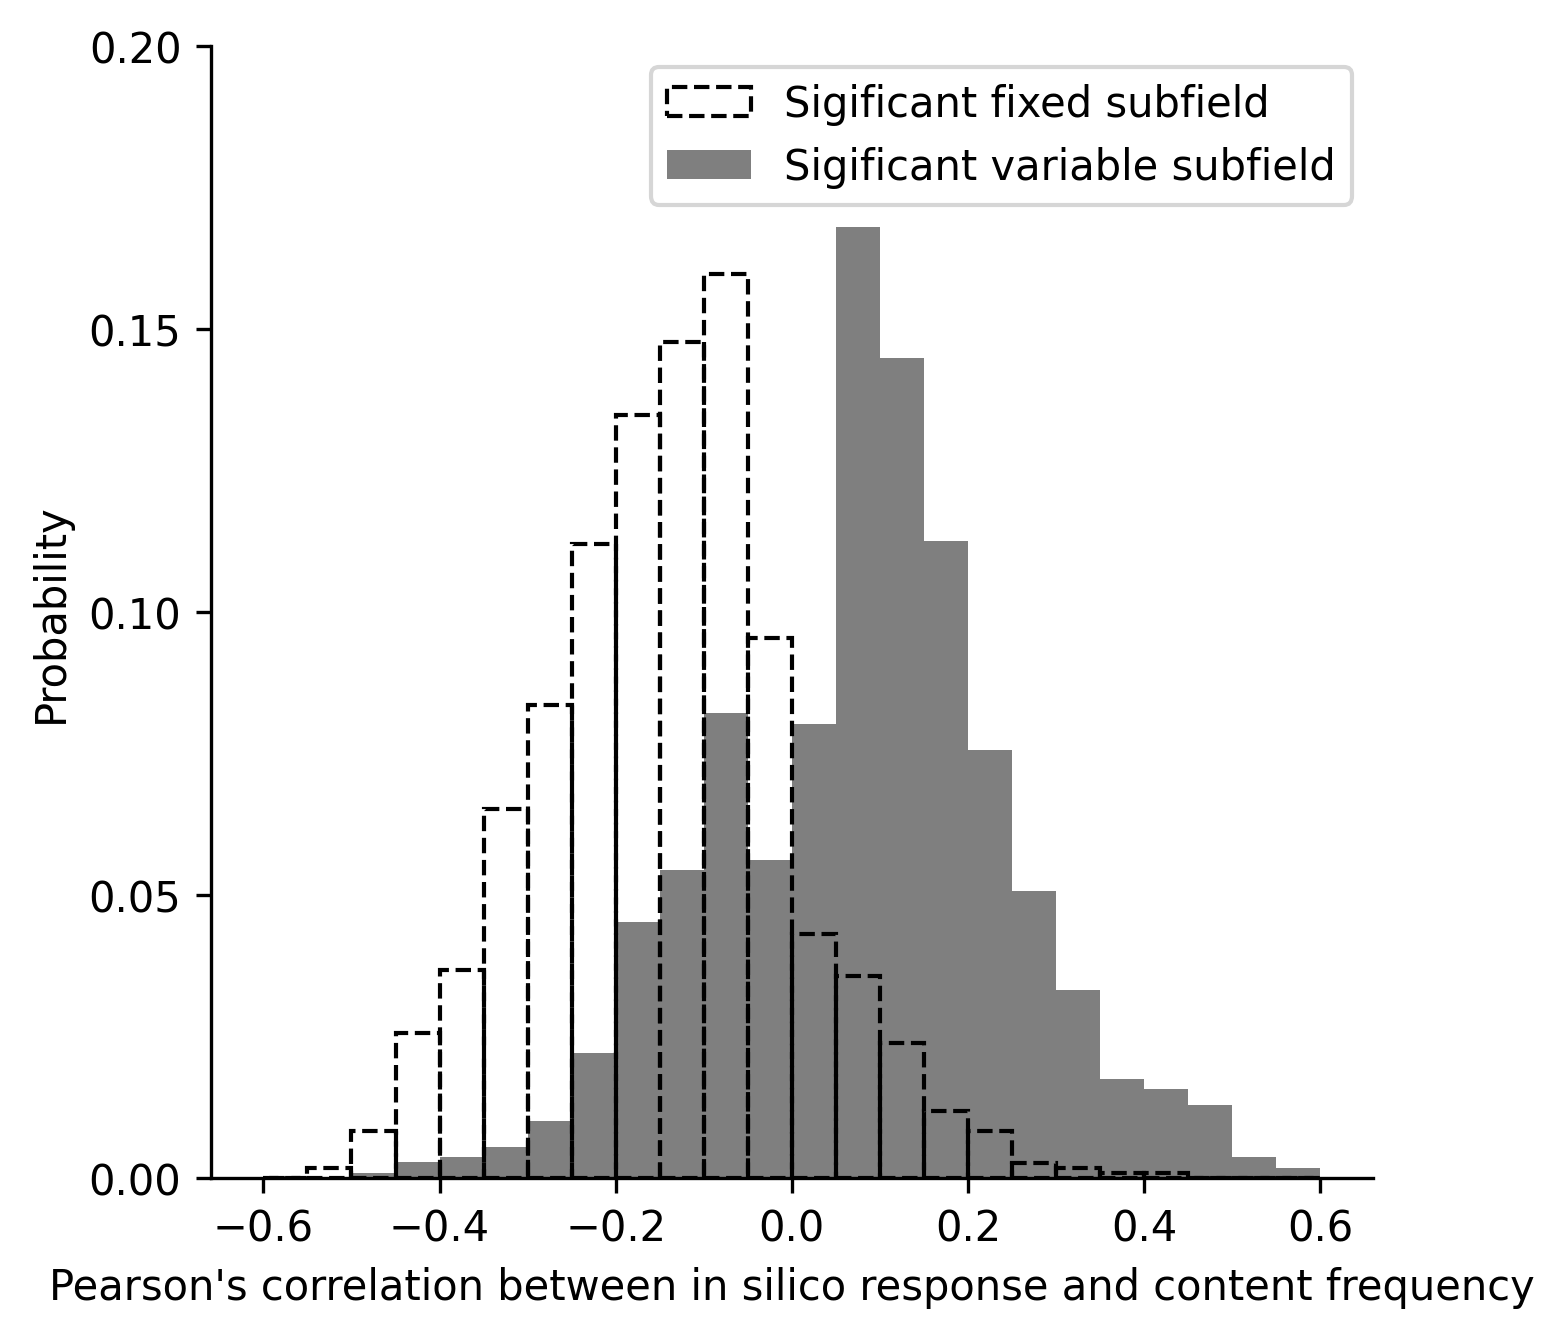

In [604]:
plt.figure(figsize=(5, 5), dpi=300)
#ax = sns.histplot(rs1[corrected_ps1<=0.05], color='b', stat='probability', binwidth=0.05, binrange=[-0.6,0.6], label='Sigificant fixed subfield', alpha=0.5, linewidth=0)
ax = sns.histplot(rs1[corrected_ps1<=0.05], color='k', stat='probability', binwidth=0.05, binrange=[-0.6,0.6], label='Sigificant fixed subfield', fill=False, linestyle='--', linewidth=1)

#ax1 = sns.histplot(rs1, color='r', stat='probability', binwidth=0.05, binrange=[-0.6,0.6], label='All fixed subfield', fill=False, linestyle='--', linewidth=1)
ax2 = sns.histplot(rs2[corrected_ps2<=0.05], color='k', stat='probability', binwidth=0.05, binrange=[-0.6,0.6], label='Sigificant variable subfield', alpha=0.5, linewidth=0)
#ax3 = sns.histplot(rs2, color='b', stat='probability', binwidth=0.05, binrange=[-0.6,0.6], label='All variable subfield', fill=False, linestyle='--', linewidth=1)

# ax3 = sns.histplot(simp_res, color='b', stat='density', binwidth=0.5, binrange=[-3.0, 0.0], label='Ideal simple cells', alpha=0.5, linewidth=0)
# ax = sns.histplot(all_res, color='gray', stat='density', binwidth=0.5, binrange=[-7.5, 6.5], label='All real neurons', linewidth=0)
# ax1 = sns.histplot(loop_res, color='k', stat='density', binwidth=0.5, binrange=[0.5, 6], label='Closed loop neurons', fill=False, linestyle='--', linewidth=1)
# ax1 = sns.histplot(loop_res, color='k', stat='density', binwidth=0.5, binrange=[-2, 5], label='Closed loop neurons', fill=False, linestyle='--', linewidth=1)

plt.legend(fontsize=10)
sns.despine()
plt.yticks([0,0.05,0.1,0.15,0.2])
plt.xlabel('Pearson\'s correlation between in silico response and content frequency')
plt.savefig("freq_pref.pdf",bbox_inches='tight',transparent=True,pad_inches = 0)


In [596]:
np.median(rs2[corrected_ps2<=0.05])

0.09049052406683664

In [590]:
import scipy.stats
print(scipy.stats.ttest_1samp(rs1[corrected_ps1<=0.05],0,alternative='less'))
print(scipy.stats.ttest_1samp(rs2[corrected_ps2<=0.05],0,alternative='greater'))
print(scipy.stats.ttest_ind(rs2[corrected_ps1<=0.05],rs1[corrected_ps1<=0.05],equal_var=False,alternative='greater'))


TtestResult(statistic=-33.384687627864224, pvalue=3.652020473163591e-169, df=1089)
TtestResult(statistic=16.234268674377574, pvalue=1.6335049448669748e-53, df=1083)
Ttest_indResult(statistic=32.84279920234693, pvalue=2.847179307267272e-192)


# 5e

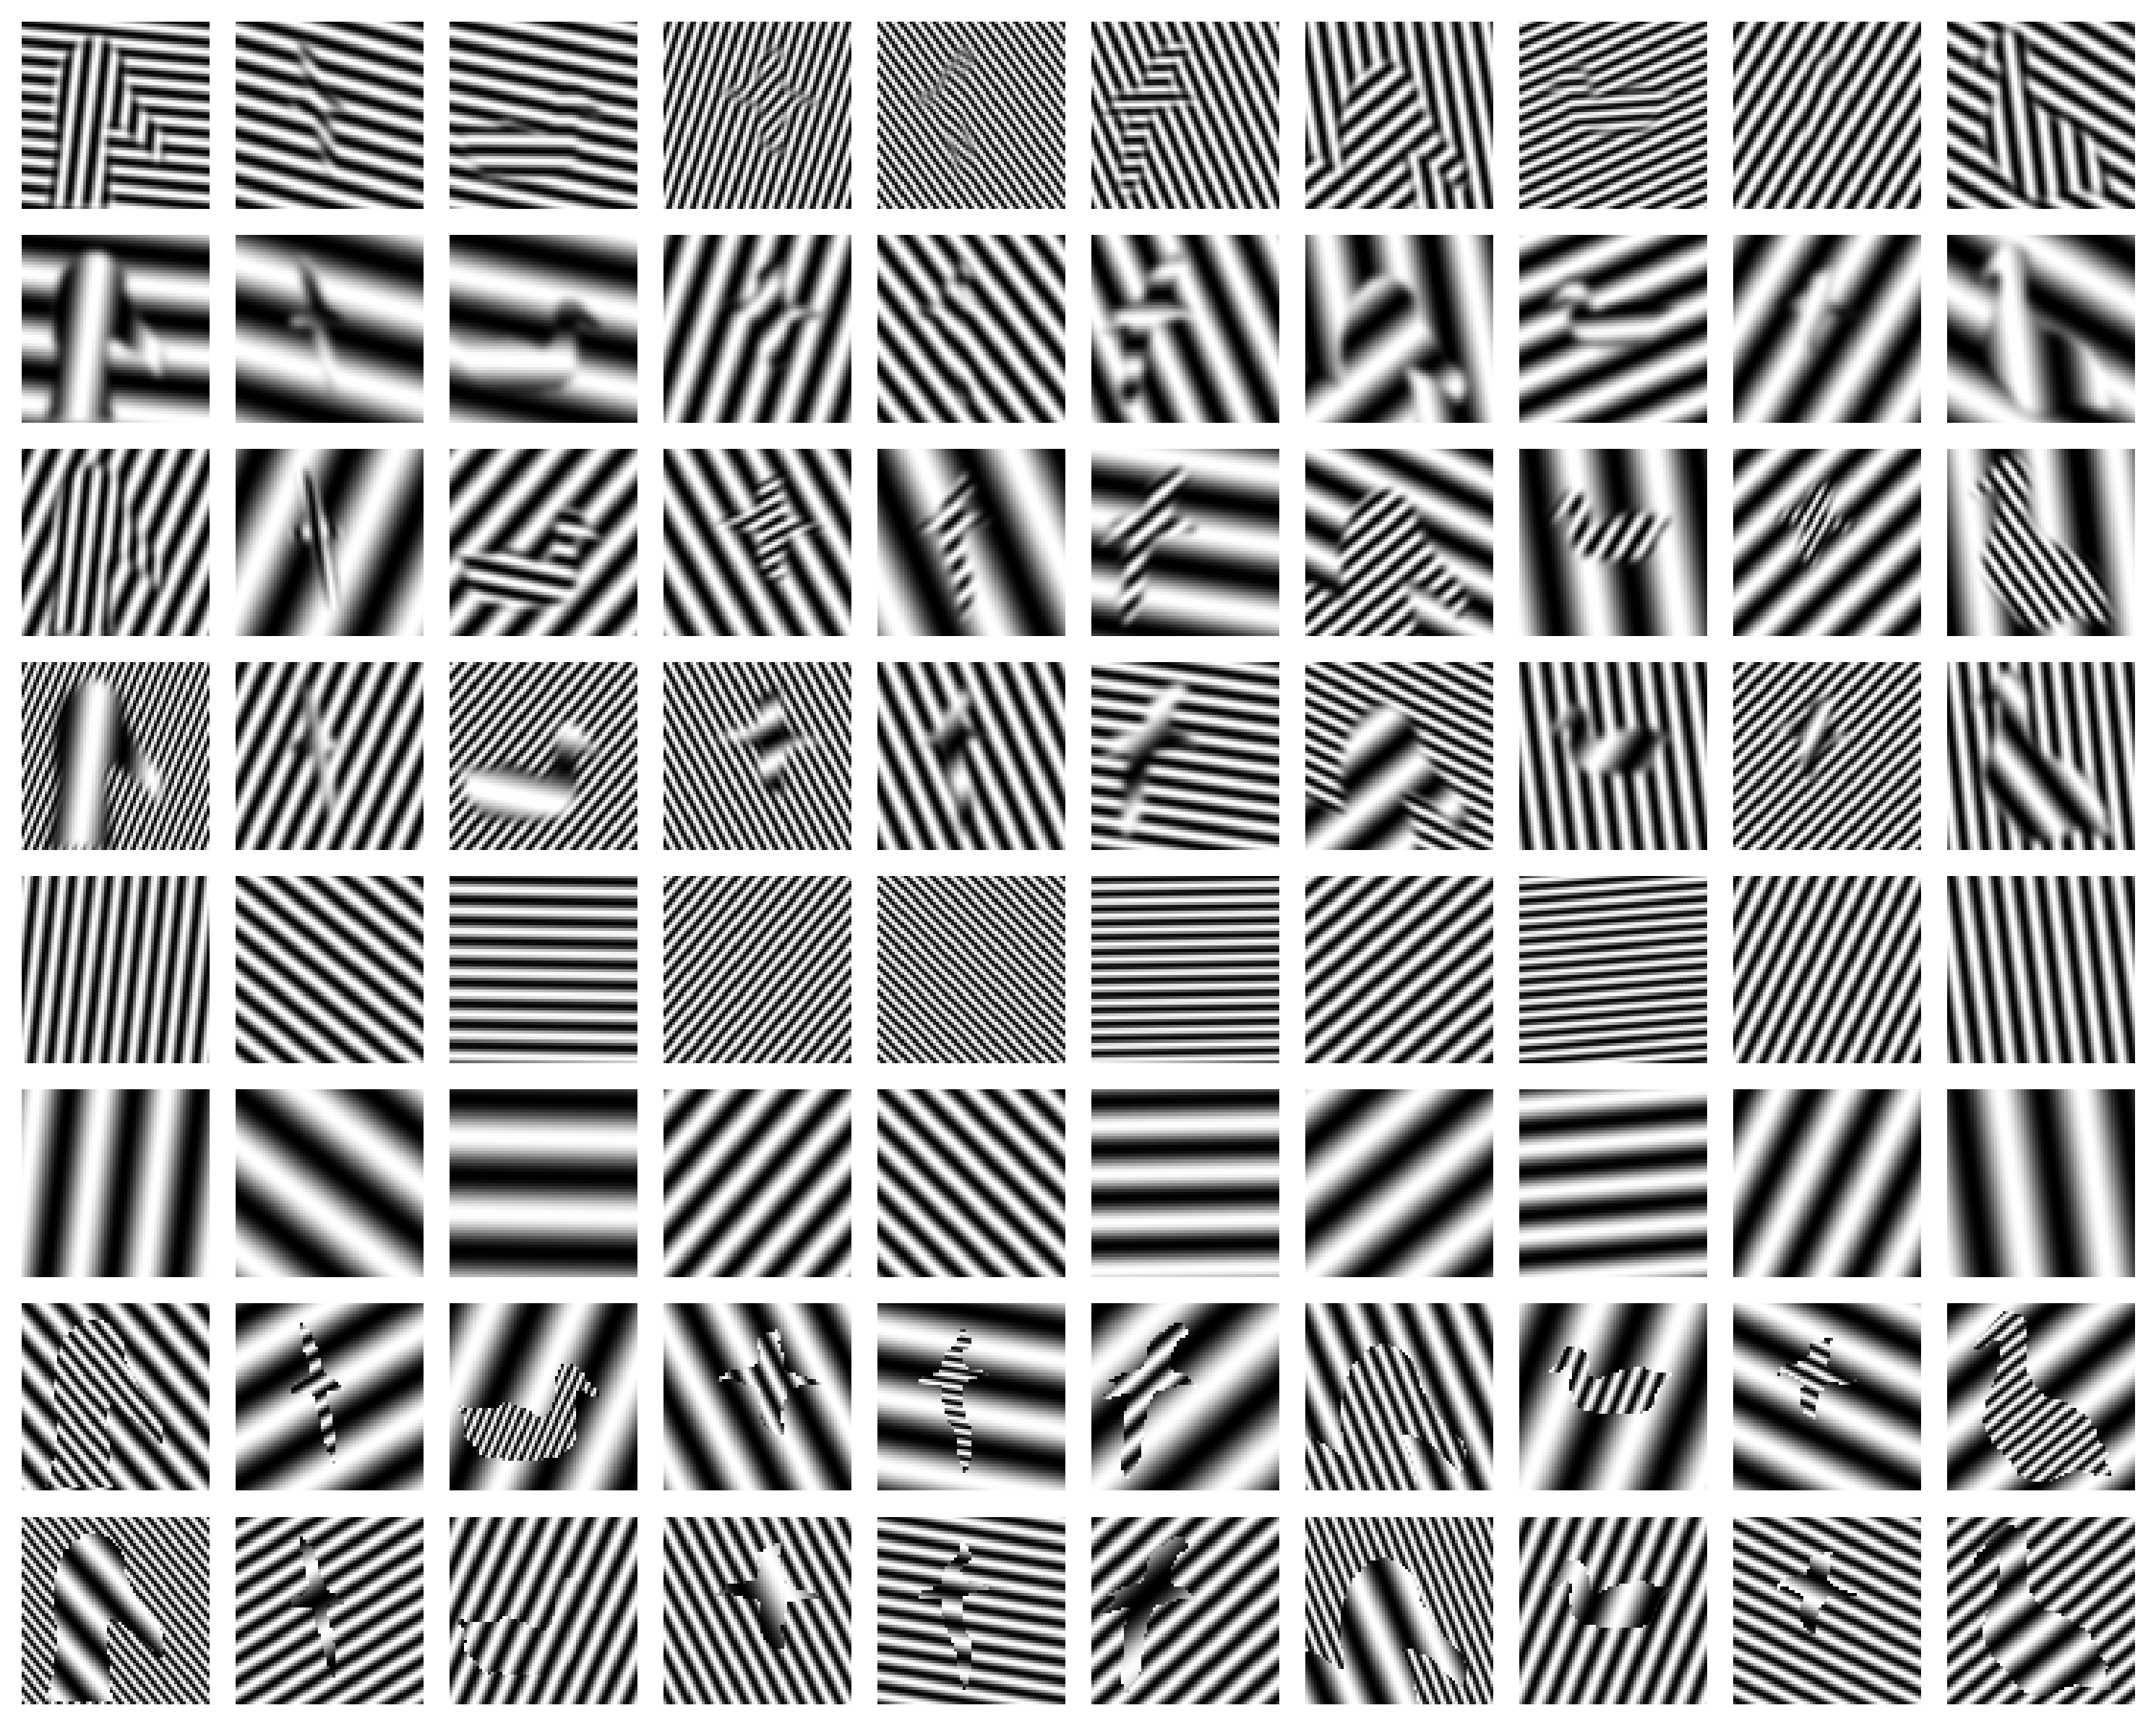

In [543]:
imgs = [(ImageDataset & {'dataset_params':i}).fetch('image',limit=10) for i in [16,17,18,19,20,21,24,25]]
fig,axs = plt.subplots(8,10,figsize=(10,8),dpi=300)
for i,j in enumerate(imgs):
    for k,l in enumerate(j):
        axs[i][k].imshow(l,cmap='gray',vmin=0,vmax=1)
        axs[i][k].axis('off')
plt.tight_layout()
sns.despine()
plt.savefig("fig_5d.pdf",bbox_inches='tight',transparent=True,pad_inches = 0)
        

# 5f

In [41]:
from collections import Counter
a = Counter(fig_5f_real)
b = Counter(fig_5f_simple)
c = Counter(fig_5f_complex)
# b = Counter(fig_5f_simple_no_blur)
# c = Counter(fig_5f_complex_no_blur)

names = ['single_grating','same_freq\ndiff ori','same_ori\ndiff freq','diff_freq\ndiff ori']
a = np.array([a[i] for i in names])
b = np.array([b[i] for i in names])
c = np.array([c[i] for i in names])
a = a*100/a.sum()
b= b*100/b.sum()
c = c*100/c.sum()
height = np.stack([a,b,c]).T.ravel()

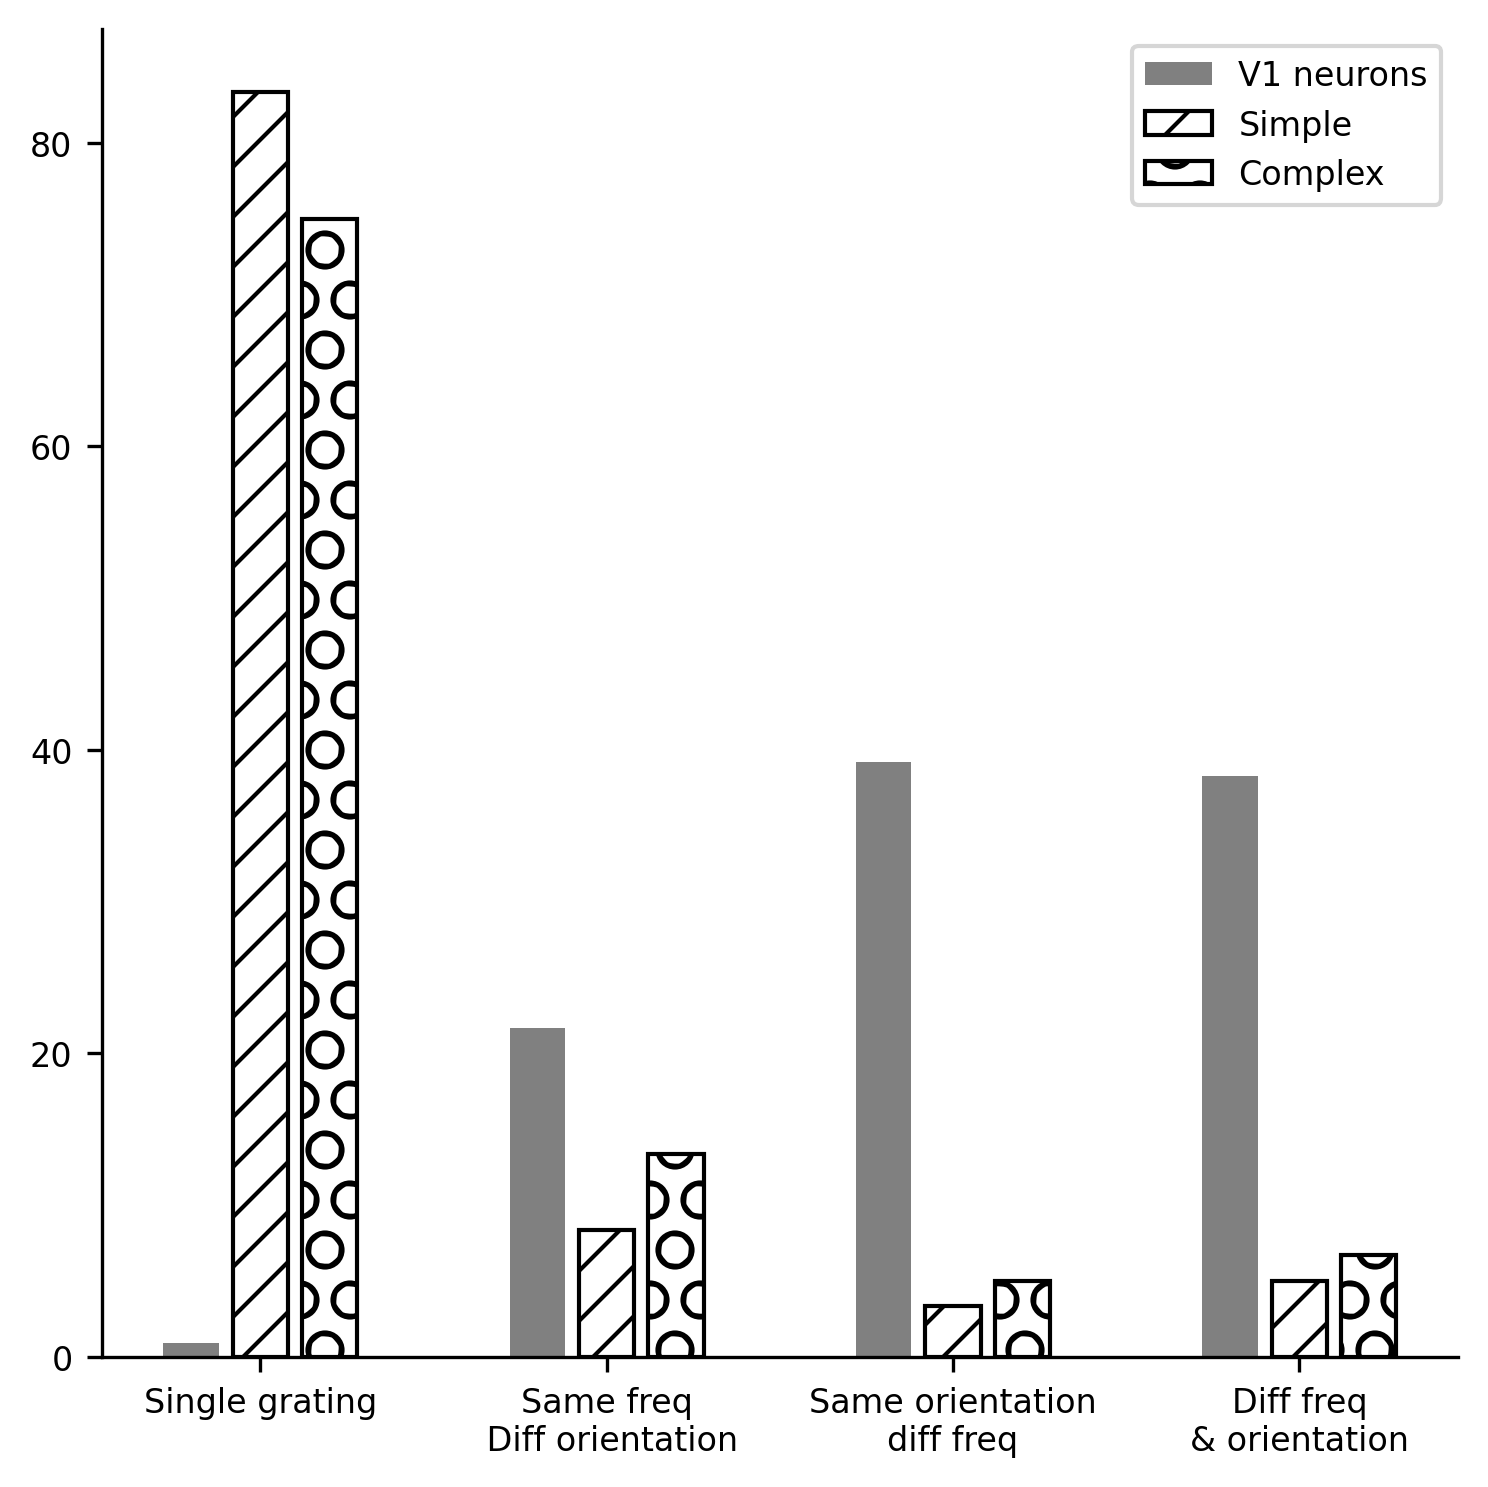

In [78]:
plt.figure(figsize=(5, 5), dpi=300)
plt.rcParams.update({'font.size': 8})
plt.bar(np.arange(0,20,5), a,fill=True,linewidth=0,color='gray',label='V1 neurons')
plt.bar(np.arange(1,20,5), b, edgecolor='black', hatch="//",fill=False,label='Simple')
plt.bar(np.arange(2,20,5), c,edgecolor='black', hatch="O",fill=False,label='Complex')
plt.legend()
plt.xticks([1,6,11,16],['Single grating','Same freq\n Diff orientation','Same orientation\ndiff freq','Diff freq\n& orientation'])
sns.despine()
plt.yticks([0,20,40,60,80])
plt.tight_layout()
#plt.savefig("fig_5f.pdf",bbox_inches='tight',transparent=True,pad_inches = 0)

In [22]:
def bootstrap_test_for_diff(n_bootstrap,pair1,pair2):
    np.random.seed(0)
    samples = np.array([0]*pair1[0] + [1]*pair1[1])
    compare_stat = pair2[1]-pair2[0]
    stats = []
    for _ in tqdm(range(n_bootstrap)):
        new_sample = np.random.choice(samples,len(samples),replace=True)
        stat = 2*new_sample.sum() - len(new_sample)
        stats.append(stat)
    stats = np.array(stats)
    summary_diffs = stats-compare_stat

    p_tests = {'<0':(summary_diffs<0.0).sum()/len(summary_diffs),
               '>0':(summary_diffs>=0.0).sum()/len(summary_diffs)}
    return min(p_tests.values())*2

In [23]:
bootstrap_test_for_diff(1000000,pair1=(11+470,260+459),pair2=(11+260,470+459))

100%|██████████| 1000000/1000000 [00:32<00:00, 31093.00it/s]


0.0

In [14]:
def bootstrap_test_for_diff(n_bootstrap,pair1,pair2):
    np.random.seed(0)
    samples1 = np.array([0]*pair1[0] + [1]*pair1[1])
    samples2 = np.array([0]*pair2[0] + [1]*pair2[1])
    stats1,stats2 = [],[]
    for _ in tqdm(range(n_bootstrap)):
        new_sample1 = np.random.choice(samples1,len(samples1),replace=True)
        stat1 = 2*new_sample1.sum() - len(new_sample1)
        stats1.append(stat1)
        new_sample2 = np.random.choice(samples2,len(samples2),replace=True)
        stat2 = 2*new_sample2.sum() - len(new_sample2)
        stats2.append(stat2)
        
    stats1 = np.array(stats1)
    stats2 = np.array(stats2)
    
    return get_CI(stats1),get_CI(stats2)
def get_CI(x,ci=95):
    return np.percentile(x,(100-ci)/2),np.percentile(x,100-(100-ci)/2)

In [15]:
# a,b = bootstrap_test_for_diff(10000,pair1=(11+470,260+459),pair2=(11+260,470+459))

100%|██████████| 10000/10000 [00:00<00:00, 13000.51it/s]


In [25]:
# print(a,b)

[ 11 260 470 459] [83.33333333  8.33333333  3.33333333  5.        ]


In [46]:
from scipy.stats import chisquare
a = Counter(fig_5f_real)
names = ['single_grating','same_freq\ndiff ori','same_ori\ndiff freq','diff_freq\ndiff ori']
a = np.array([a[i] for i in names])
print(chisquare(a,(b/100)*a.sum()))
print(chisquare(a,(c/100)*a.sum()))


Power_divergenceResult(statistic=8509.971, pvalue=0.0)
Power_divergenceResult(statistic=5537.813611111111, pvalue=0.0)


In [43]:
a

array([ 11, 260, 470, 459])

# 5g

In [124]:
print(len(fig_5g))

929


929
WilcoxonResult(statistic=340648.0, pvalue=9.891323494572016e-53)


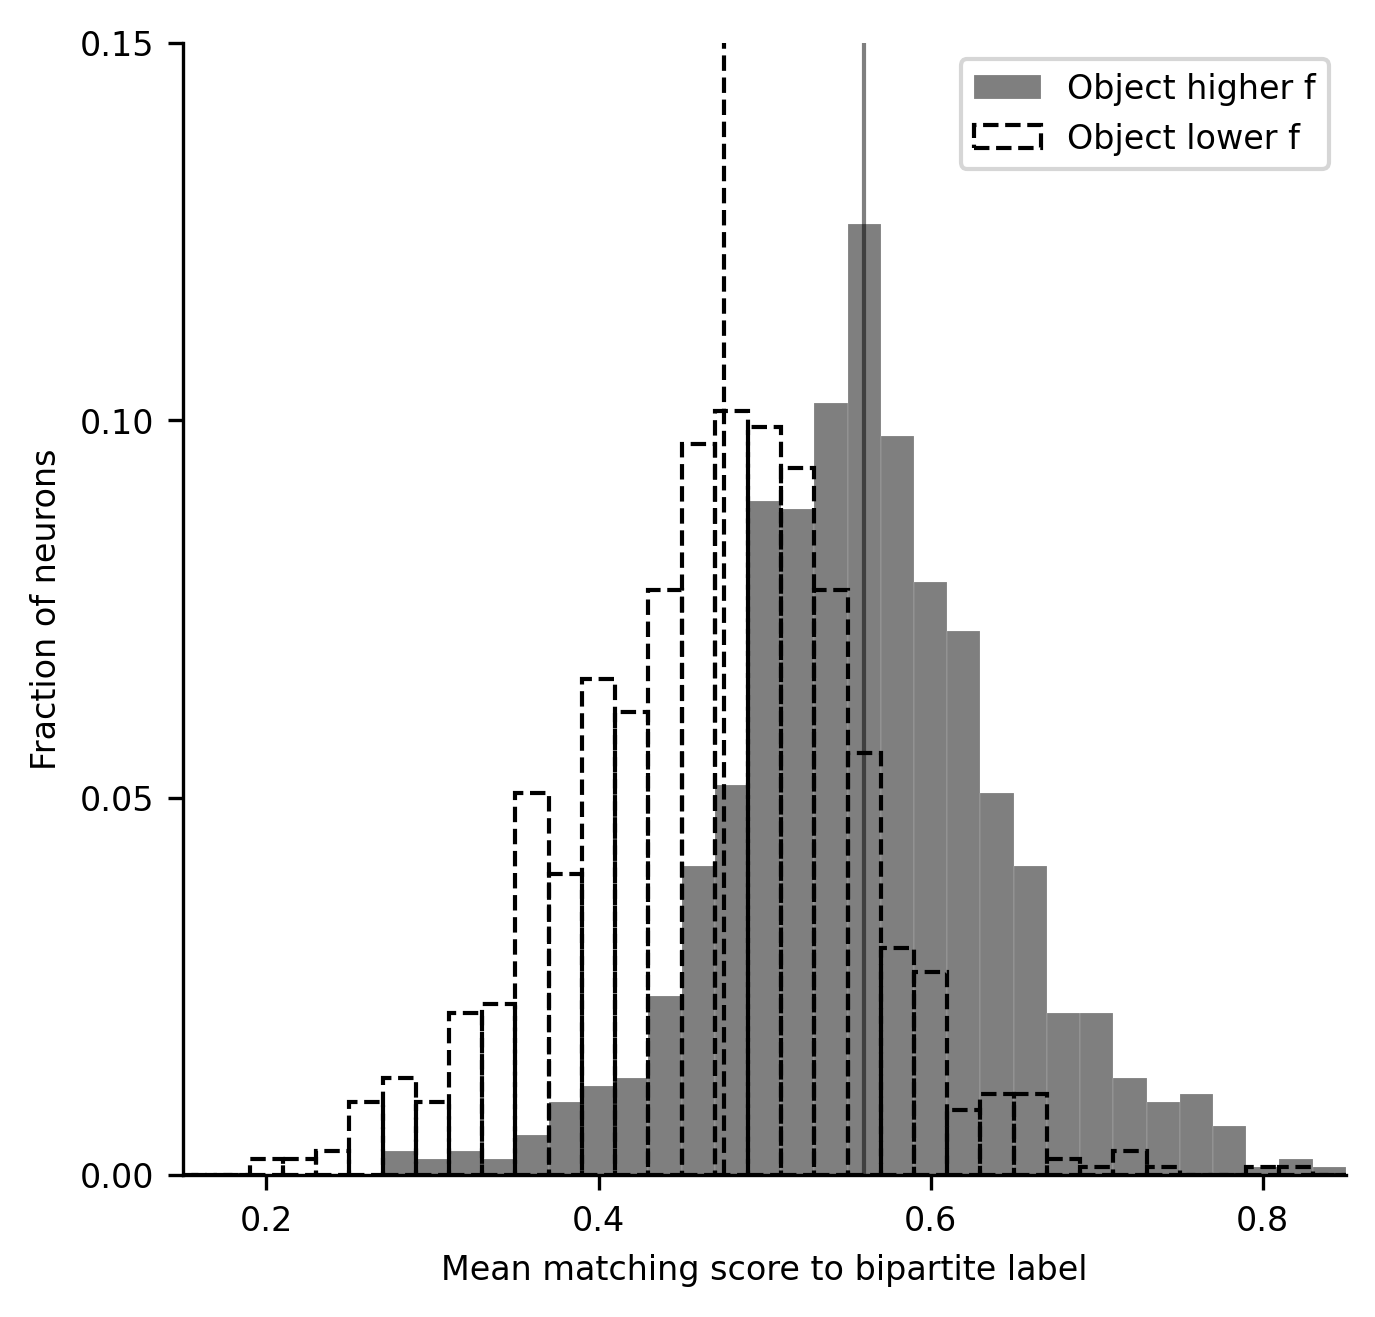

In [125]:
x = np.array([i[0].mean() for i in fig_5g])
y = np.array([i[1].mean() for i in fig_5g])
idxs = np.where(~np.logical_or(np.isnan(x),np.isnan(y)))[0]
x = x[idxs]
y = y[idxs]
print(len(idxs))
plt.figure(figsize=(5, 5), dpi=300)
print(wilcoxon(x,y,alternative='greater'))
sns.histplot(x,color='k',alpha=0.5,stat='probability',kde=False,binrange=[0.15,0.85],binwidth=0.02,label='Object higher f',edgecolor="white", linewidth=0.04)
sns.histplot(y,color='k',alpha=1,stat='probability',kde=False,binrange=[0.15,0.85],binwidth=0.02,label='Object lower f', fill=False,linewidth=1,linestyle='--')
plt.axvline(x=np.median(x),c='k',alpha=0.5,linewidth=1)
plt.axvline(x=np.median(y),c='k',linestyle='--',alpha=1,linewidth=1)

plt.xlabel('Mean matching score to bipartite label')
plt.ylabel('Fraction of neurons')
plt.legend()
sns.despine()
plt.xticks([0.2,0.4,0.6,0.8])
plt.xlim(0.15,0.85)
plt.yticks([0,0.05,0.1,0.15])
plt.ylim(0,0.15)
plt.savefig("5f.pdf",bbox_inches='tight',transparent=True,pad_inches = 0)

# 5c

In [6]:
from staticnet_invariance.deis_reconfigured import *
from staticnet_invariance import deis_reconfigured as deis_schema
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, fftfreq
import scipy.stats as stats
import seaborn as sns

In [7]:
rest1 = {'diverse_params': 14, 'texture_params':20,'score_params':2}
rest2 = {'diverse_params': 17, 'texture_params':20,'score_params':2}
keys = (deis_schema.NeuronSetRequest & 'method_id=3').fetch(as_dict=True)
device='cuda:0'

In [8]:
def cal_power_spectrum(img):
    img = (img - img.mean()) / img.std()
    amp = np.abs(fft2(img))
    return fftshift(amp)
def cal_radial(power_spectrum,bins=None,cut_off=0.5):
    dist,power = [],[]
    h, w = power_spectrum.shape
    center_h, center_w = h/2, w/2
    for i in range(h):
        for j in range(w):
            temp_dist = np.sqrt((i - center_h)**2 + (j - center_w)**2)
            if temp_dist<=min(power_spectrum.shape):
                dist.append(temp_dist)
                power.append(power_spectrum[i,j])
    dist = np.array(dist)
    power = np.array(power)
    if bins is None:
        bins = min(power_spectrum.shape)
    avg, edges, _ = stats.binned_statistic(dist, power, bins=bins)
    
    coords = (edges[:-1] + edges[1:])/2
    x = np.linspace(coords[0],coords[-1],10000)
    power_predicted = np.interp(x,coords,avg)
    freq_reported = x[np.argmin(abs(np.cumsum(power_predicted)-power_predicted.sum()*cut_off))]
    return coords, avg, freq_reported

In [9]:
class LinearImageModel(nn.Module):
    # mei, mask, v_mask is numpy array
    def __init__(self,mei,v_mask,t_f='c_f_scaled',t_shape=(72, 128),eval_padding=(0,0,0,0),center_padding=(0,0,0,0),default_n_crops=64, eval_texture=None, device='cuda'):
        
        super(LinearImageModel,self).__init__()
        self.device = device
        self.eval_padding = eval_padding
        self.center_padding = center_padding
        
        self.mei_f = ops.ChangeStats(mean=mei.mean(),std=mei.std())
        fixed_c = mei * (1.0-v_mask)
        var_c = mei * v_mask
        self.var_c_f = ops.ChangeStats(mean = var_c.mean(),std = var_c.std())
        if t_f == 'c_f_scaled':
            # Ratio to compensate for empty space in texture
            ratio_for_empty_space = 1.3
            self.var_t_f = ops.ChangeStats(mean = var_c.mean(),std = var_c.std() * np.sqrt(v_mask.size/v_mask.sum()) * ratio_for_empty_space)
        elif t_f == 'c_f':
            self.var_t_f = self.var_c_f
        self.register_buffer('fixed_c',torch.tensor(np.array(fixed_c),dtype=torch.float32).unsqueeze(0).unsqueeze(0).contiguous())
        self.register_buffer('v_mask',torch.tensor(np.array(v_mask),dtype=torch.float32))
        
        self.image_shape = var_c.shape
        self.t_shape = t_shape
        self.initialize_t()
        self.default_n_crops = default_n_crops

        # Hack for evaluation of a pre-optimized texture
        if eval_texture is not None:
            self.register_buffer('eval_texture',torch.tensor(np.array(eval_texture),dtype=torch.float32).unsqueeze(0).unsqueeze(0).contiguous())
        else: self.eval_texture = eval_texture
        
    def initialize_t(self,initial_t=None):
        if initial_t is not None:
            if not initial_t.shape[-2:] == self.t_shape:
                raise ValueError('Initial t shape is wrong from t_shape')
            self.t = nn.Parameter(torch.tensor(initial_t[None, None], dtype=torch.float32, device=self.device).contiguous())
        else:
            self.t = nn.Parameter(torch.randn(1, 1, self.t_shape[0], self.t_shape[1], device=self.device))
        self.standardize_t_f()

    def standardize_t_f(self):
        with torch.no_grad():
            self.t.data = self.var_t_f(self.t.data)
            
    def get_v_c(self,n_crops=None,key='full'):
        if n_crops is None:
            n_crops = self.default_n_crops
        v_c, crop_x, crop_y = ops.RandomCrop(self.image_shape[0], self.image_shape[1], n_crops)(self.get_texture(key=key,in_numpy_format=False))
        v_c = v_c*self.v_mask[None,None,:,:]
        v_c = self.var_c_f(v_c)
        return v_c, crop_x, crop_y
    
    def forward(self,n_crops=None,key='full'):
        return self.mei_f(self.fixed_c + self.get_v_c(n_crops,key)[0])
    
    def get_texture(self,key='centered',in_numpy_format=True):
        x = self.t
        if key != 'full':
            if key == 'centered':
                padding = self.center_padding
            elif key == 'eval':
                # Hack for evaluation of a pre-optimized texture
                if self.eval_texture is not None:
                    x = self.eval_texture
                    if in_numpy_format:
                        x = x.detach().cpu().numpy().squeeze()
                    return x
                padding = self.eval_padding
            else:
                raise ValueError(key + ' is not specified')
            x = x[:,:,padding[0]:-padding[1],padding[2]:-padding[3]]
            
        if in_numpy_format:
            x = x.detach().cpu().numpy().squeeze()
        return x

In [10]:
results,ps = [],[]
for key in tqdm(keys):
    if key['group_id']<=237:
        rest = rest1
    else: 
        rest=rest2
    eval_texture,samples,variable_mask,mei_mask,mask_x,mask_y,p = (MEIMask * deis_schema.Texture * deis_schema.TextureGoodRun & key & rest).fetch1('eval_texture','samples','variable_mask','mask','mask_x','mask_y','p')
    ps.append(p)
    samples = np.stack([ops.center_and_crop_image(i,mask_x,mask_y,output_size=(32,32))[0] for i in samples])
    
    texture_crops = ops.RandomCrop(36, 64, 20)(torch.tensor(np.array(eval_texture)).unsqueeze(0).unsqueeze(0))[0].detach().cpu().numpy().squeeze()
    texture_crops = ops.standardize_image(texture_crops, mask = mei_mask,target_mean=0.0, target_std=0.25, mask_mean_subtraction=True,mask_image=True,match_stats='ff')
    # One sample to keep
    kept_sample = np.array(texture_crops[3])
    texture_crops = np.stack([ops.center_and_crop_image(i,mask_x,mask_y,output_size=(32,32))[0] for i in texture_crops])
    
    # Modify kept_sample to match mean and std of each component
    mei = (MEI * deis_schema.Texture * deis_schema.TextureGoodRun & key & rest).fetch1('mei')
    v_comp = mei * variable_mask
    f_mask = np.clip(mei_mask-variable_mask,a_min=0,a_max=1)
    f_comp = mei - v_comp
    
    kept_v = kept_sample * variable_mask
    kept_v = (((kept_v - kept_v.mean()) * v_comp.std())/(kept_v.std()+1e-9))+v_comp.mean()
    kept_f = kept_sample * f_mask
    kept_f = (((kept_f - kept_f.mean()) * f_comp.std())/(kept_f.std()+1e-9))+f_comp.mean()
    
    kept_sample = kept_v + kept_f
    kept_sample = (((kept_sample - kept_sample.mean()) * mei.std())/(kept_sample.std()+1e-9))+mei.mean()
    
    # Replace mei by one image crop
    image_model = LinearImageModel(kept_sample,variable_mask,eval_texture=eval_texture).to(device)
    control_deis  = deis_schema.Texture.select_texture_dei(image_model,dei=None,sample_criterion='random',n_sample=20,batch_size=64,device='cuda')
    control_deis = np.stack([ops.center_and_crop_image(i,mask_x,mask_y,output_size=(32,32))[0] for i in control_deis])
    
    x_fft = np.stack([cal_power_spectrum(i) for i in samples])
    y_fft = np.stack([cal_power_spectrum(i) for i in texture_crops])
    z_fft = np.stack([cal_power_spectrum(i) for i in control_deis])
    
    x_dist,x_power,_ = cal_radial(x_fft.mean(axis=0))
    y_dist,y_power,_ = cal_radial(y_fft.mean(axis=0))
    z_dist,z_power,_ = cal_radial(z_fft.mean(axis=0))

    x_freq_report = np.array([cal_radial(i)[2] for i in x_fft])
    y_freq_report = np.array([cal_radial(i)[2] for i in y_fft])
    z_freq_report = np.array([cal_radial(i)[2] for i in z_fft])
    
    results.append({'Partial DEI':{'img':samples,'fft':x_fft,'dist':x_dist,'power':x_power,'freq_reported':x_freq_report},
                   'Full control':{'img':texture_crops,'fft':y_fft,'dist':y_dist,'power':y_power,'freq_reported':y_freq_report},
                   'Partial control':{'img':control_deis,'fft':z_fft,'dist':z_dist,'power':z_power,'freq_reported':z_freq_report}})
ps = np.array(ps)

100%|██████████| 1200/1200 [04:14<00:00,  4.71it/s]


In [11]:
degree_per_pixel = 1.94333333333
x_freqs = np.stack([i['Partial DEI']['freq_reported'] for i in results])/(32*degree_per_pixel)
y_freqs = np.stack([i['Full control']['freq_reported'] for i in results])/(32*degree_per_pixel)
z_freqs = np.stack([i['Partial control']['freq_reported'] for i in results])/(32*degree_per_pixel)


In [12]:
from staticnet_invariance import toy, toy_deis
simple_rest = {'group_id': 6,'neuron_type':"Simple", 'config_id':1,'mei_params': 1, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2},
complex_rest = {'group_id': 6,'neuron_type':"Complex", 'config_id':1,'mei_params': 1, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2},
simple_rest = {'group_id': 6,'neuron_type':"Simple", 'config_id':1,'mei_params': 1, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2},
complex_rest = {'group_id': 6,'neuron_type':"Complex", 'config_id':1,'mei_params': 1, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2},
       
simple_keys = (toy.GroupAssignment.Member * toy_deis.MEIMask & simple_rest).fetch('KEY',order_by='neuron_type,member_id')
complex_keys = (toy.GroupAssignment.Member * toy_deis.MEIMask & complex_rest).fetch('KEY',order_by='neuron_type,member_id')

In [13]:
min_plot = min(np.concatenate([x_freqs.mean(axis=1),y_freqs.mean(axis=1),z_freqs.mean(axis=1)]))
max_plot = max(np.concatenate([x_freqs.mean(axis=1),y_freqs.mean(axis=1),z_freqs.mean(axis=1)]))
max_plot = 0.2

In [14]:
simple_results = []
for key in tqdm(simple_keys):
    rest = {'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2}
    eval_texture,samples,variable_mask,mei_mask,mask_x,mask_y,p = (toy_deis.MEIMask * toy_deis.DEINewGoodRunLookup * toy_deis.Texture * toy_deis.TextureGoodRun & rest & key).fetch1('eval_texture','samples','variable_mask','mask','mask_x','mask_y','p')
    samples = np.stack([ops.center_and_crop_image(i,mask_x,mask_y,output_size=(32,32))[0] for i in samples])
    
    texture_crops = ops.RandomCrop(36, 64, 20)(torch.tensor(np.array(eval_texture)).unsqueeze(0).unsqueeze(0))[0].detach().cpu().numpy().squeeze()
    texture_crops = ops.standardize_image(texture_crops, mask = mei_mask,target_mean=0.0, target_std=0.25, mask_mean_subtraction=True,mask_image=True,match_stats='ff')
    # One sample to keep
    kept_sample = np.array(texture_crops[3])
    texture_crops = np.stack([ops.center_and_crop_image(i,mask_x,mask_y,output_size=(32,32))[0] for i in texture_crops])
    
    mei = (toy_deis.MEI & key).fetch1('mei')
    v_comp = mei * variable_mask
    f_mask = np.clip(mei_mask-variable_mask,a_min=0,a_max=1)
    f_comp = mei - v_comp
    
    kept_v = kept_sample * variable_mask
    kept_v = (((kept_v - kept_v.mean()) * v_comp.std())/(kept_v.std()+1e-9))+v_comp.mean()
    kept_f = kept_sample * f_mask
    kept_f = (((kept_f - kept_f.mean()) * f_comp.std())/(kept_f.std()+1e-9))+f_comp.mean()
    
    kept_sample = kept_v + kept_f
    kept_sample = (((kept_sample - kept_sample.mean()) * mei.std())/(kept_sample.std()+1e-9))+mei.mean()
    
    # Replace mei by one image crop
    image_model = LinearImageModel(kept_sample,variable_mask,eval_texture=eval_texture).to(device)
    control_deis  = deis_schema.Texture.select_texture_dei(image_model,dei=None,sample_criterion='random',n_sample=20,batch_size=64,device='cuda')
    control_deis = np.stack([ops.center_and_crop_image(i,mask_x,mask_y,output_size=(32,32))[0] for i in control_deis])
    
    x_fft = np.stack([cal_power_spectrum(i) for i in samples])
    y_fft = np.stack([cal_power_spectrum(i) for i in texture_crops])
    z_fft = np.stack([cal_power_spectrum(i) for i in control_deis])
    
    x_dist,x_power,_ = cal_radial(x_fft.mean(axis=0))
    y_dist,y_power,_ = cal_radial(y_fft.mean(axis=0))
    z_dist,z_power,_ = cal_radial(z_fft.mean(axis=0))

    x_freq_report = np.array([cal_radial(i)[2] for i in x_fft])
    y_freq_report = np.array([cal_radial(i)[2] for i in y_fft])
    z_freq_report = np.array([cal_radial(i)[2] for i in z_fft])
    
    simple_results.append({'Partial DEI':{'img':samples,'fft':x_fft,'dist':x_dist,'power':x_power,'freq_reported':x_freq_report},
                   'Full control':{'img':texture_crops,'fft':y_fft,'dist':y_dist,'power':y_power,'freq_reported':y_freq_report},
                   'Partial control':{'img':control_deis,'fft':z_fft,'dist':z_dist,'power':z_power,'freq_reported':z_freq_report}})

100%|██████████| 60/60 [00:16<00:00,  3.63it/s]


In [15]:
complex_results = []
for key in tqdm(complex_keys):
    rest = {'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2}

    eval_texture,samples,variable_mask,mei_mask,mask_x,mask_y,p = (toy_deis.MEIMask * toy_deis.DEINewGoodRunLookup * toy_deis.Texture * toy_deis.TextureGoodRun & rest & key).fetch1('eval_texture','samples','variable_mask','mask','mask_x','mask_y','p')
    samples = np.stack([ops.center_and_crop_image(i,mask_x,mask_y,output_size=(32,32))[0] for i in samples])
    
    texture_crops = ops.RandomCrop(36, 64, 20)(torch.tensor(np.array(eval_texture)).unsqueeze(0).unsqueeze(0))[0].detach().cpu().numpy().squeeze()
    texture_crops = ops.standardize_image(texture_crops, mask = mei_mask,target_mean=0.0, target_std=0.25, mask_mean_subtraction=True,mask_image=True,match_stats='ff')
    # One sample to keep
    kept_sample = np.array(texture_crops[3])
    texture_crops = np.stack([ops.center_and_crop_image(i,mask_x,mask_y,output_size=(32,32))[0] for i in texture_crops])
    
    mei = (toy_deis.MEI & key).fetch1('mei')
    v_comp = mei * variable_mask
    f_mask = np.clip(mei_mask-variable_mask,a_min=0,a_max=1)
    f_comp = mei - v_comp
    
    kept_v = kept_sample * variable_mask
    kept_v = (((kept_v - kept_v.mean()) * v_comp.std())/(kept_v.std()+1e-9))+v_comp.mean()
    kept_f = kept_sample * f_mask
    kept_f = (((kept_f - kept_f.mean()) * f_comp.std())/(kept_f.std()+1e-9))+f_comp.mean()
    
    kept_sample = kept_v + kept_f
    kept_sample = (((kept_sample - kept_sample.mean()) * mei.std())/(kept_sample.std()+1e-9))+mei.mean()
    
    # Replace mei by one image crop
    image_model = LinearImageModel(kept_sample,variable_mask,eval_texture=eval_texture).to(device)
    control_deis  = deis_schema.Texture.select_texture_dei(image_model,dei=None,sample_criterion='random',n_sample=20,batch_size=64,device='cuda')
    control_deis = np.stack([ops.center_and_crop_image(i,mask_x,mask_y,output_size=(32,32))[0] for i in control_deis])
    
    x_fft = np.stack([cal_power_spectrum(i) for i in samples])
    y_fft = np.stack([cal_power_spectrum(i) for i in texture_crops])
    z_fft = np.stack([cal_power_spectrum(i) for i in control_deis])
    
    x_dist,x_power,_ = cal_radial(x_fft.mean(axis=0))
    y_dist,y_power,_ = cal_radial(y_fft.mean(axis=0))
    z_dist,z_power,_ = cal_radial(z_fft.mean(axis=0))

    x_freq_report = np.array([cal_radial(i)[2] for i in x_fft])
    y_freq_report = np.array([cal_radial(i)[2] for i in y_fft])
    z_freq_report = np.array([cal_radial(i)[2] for i in z_fft])
    
    complex_results.append({'Partial DEI':{'img':samples,'fft':x_fft,'dist':x_dist,'power':x_power,'freq_reported':x_freq_report},
                   'Full control':{'img':texture_crops,'fft':y_fft,'dist':y_dist,'power':y_power,'freq_reported':y_freq_report},
                   'Partial control':{'img':control_deis,'fft':z_fft,'dist':z_dist,'power':z_power,'freq_reported':z_freq_report}})

100%|██████████| 60/60 [00:16<00:00,  3.74it/s]


In [16]:
degree_per_pixel = 1.94333333333
simple_x_freqs = np.stack([i['Partial DEI']['freq_reported'] for i in simple_results])/(32*degree_per_pixel)
simple_y_freqs = np.stack([i['Full control']['freq_reported'] for i in simple_results])/(32*degree_per_pixel)
simple_z_freqs = np.stack([i['Partial control']['freq_reported'] for i in simple_results])/(32*degree_per_pixel)
complex_x_freqs = np.stack([i['Partial DEI']['freq_reported'] for i in complex_results])/(32*degree_per_pixel)
complex_y_freqs = np.stack([i['Full control']['freq_reported'] for i in complex_results])/(32*degree_per_pixel)
complex_z_freqs = np.stack([i['Partial control']['freq_reported'] for i in complex_results])/(32*degree_per_pixel)


In [30]:
from scipy.stats import wilcoxon
#print(wilcoxon(x_freqs.mean(axis=1),z_freqs.mean(axis=1),alternative='less'))
print(wilcoxon(x_freqs.mean(axis=1),z_freqs.mean(axis=1)))
print(wilcoxon(simple_x_freqs.mean(axis=1),simple_z_freqs.mean(axis=1)))
print(wilcoxon(complex_x_freqs.mean(axis=1),complex_z_freqs.mean(axis=1)))
#print(wilcoxon(complex_x_freqs.mean(axis=1),complex_z_freqs.mean(axis=1),alternative='less'))

WilcoxonResult(statistic=34381.0, pvalue=3.066616803831965e-162)
WilcoxonResult(statistic=302.0, pvalue=6.401880850443336e-06)
WilcoxonResult(statistic=14.0, pvalue=3.293182235624656e-11)


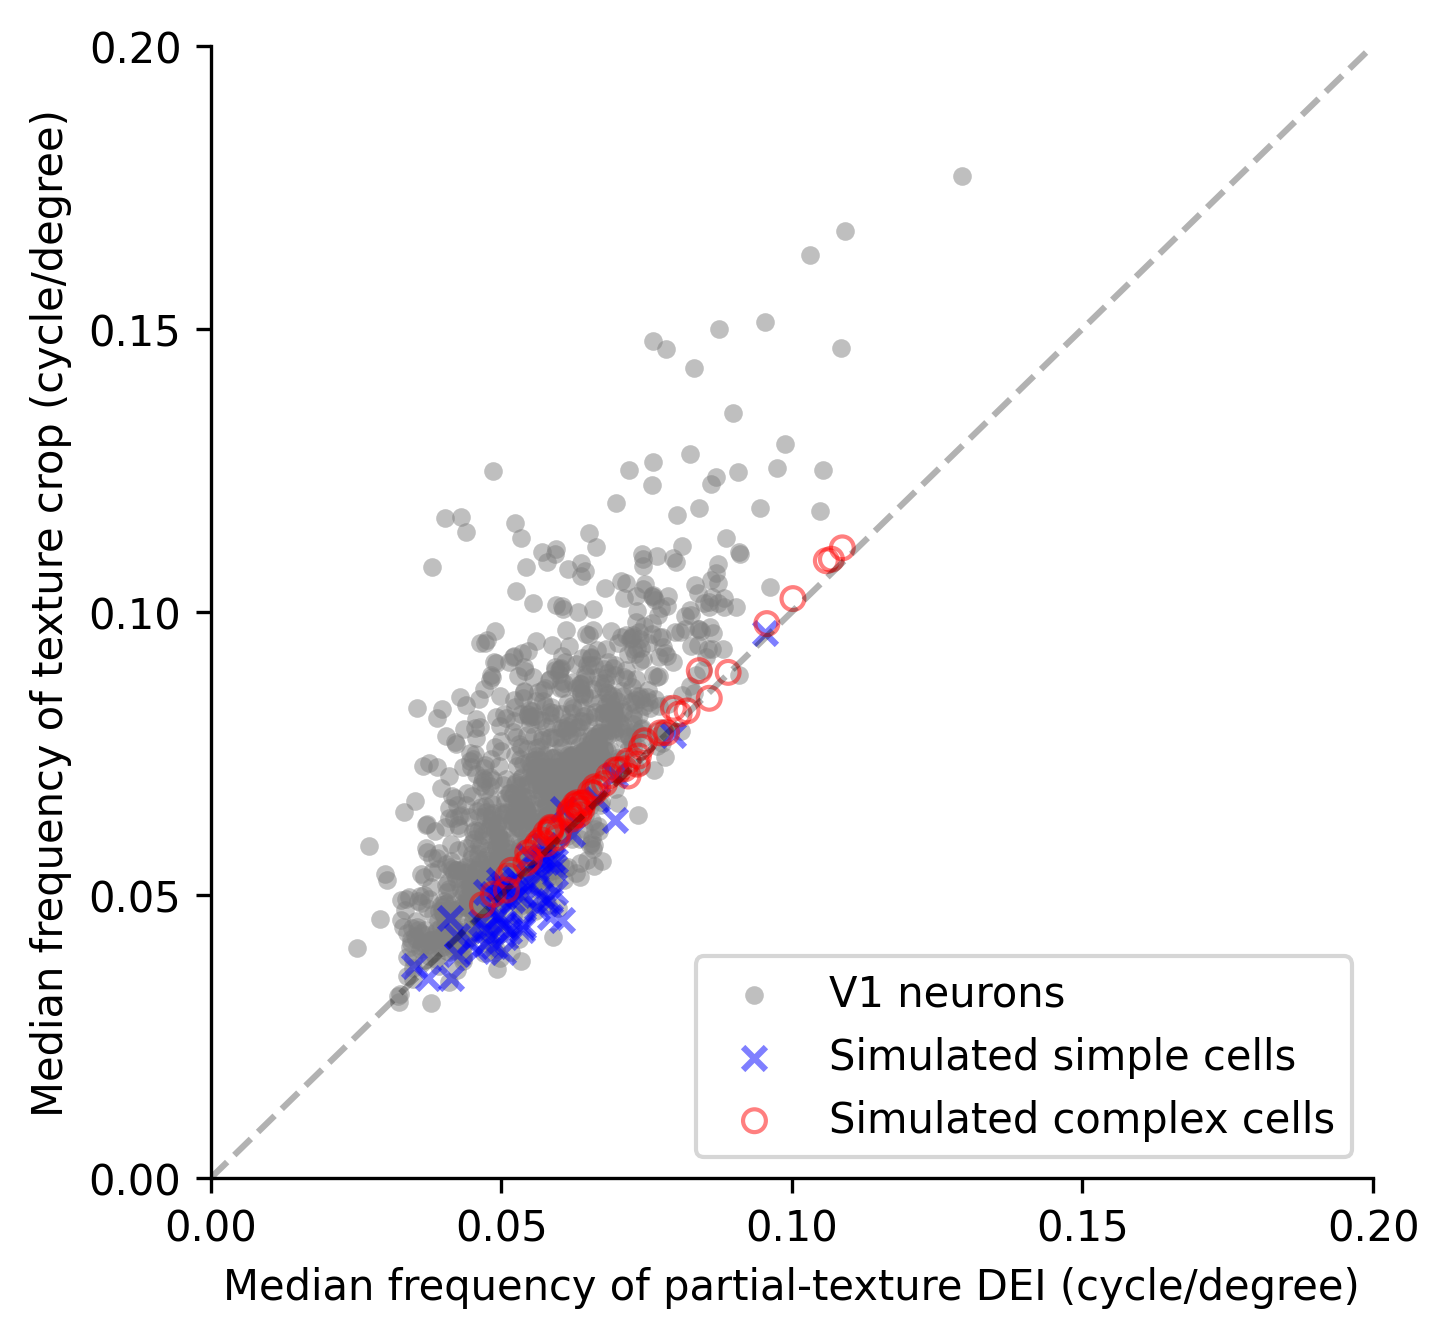

In [32]:

plt.figure(figsize=(5, 5), dpi=300)
plt.scatter(x_freqs.mean(axis=1),z_freqs.mean(axis=1),color='gray',alpha=0.5, s=20, marker='o',label='V1 neurons',linewidths=0)
# ax = sns.histplot(x=x_freqs.mean(axis=1),y=y_freqs.mean(axis=1),color='gray',alpha=1,binwidth=0.005,binrange=[0.01,0.18],label='V1 neurons',legend=True,
#                   hue_order=['a'],stat='count',cbar=True)
ax = plt.gca()
ax.scatter(simple_x_freqs.mean(axis=1),simple_z_freqs.mean(axis=1),marker='x', s=30,alpha=0.5,color='blue',label='Simulated simple cells',linewidths=1)
ax.scatter(complex_x_freqs.mean(axis=1),complex_z_freqs.mean(axis=1),marker='o',facecolors='none', edgecolors='red', s=30,alpha=0.5,label='Simulated complex cells',linewidths=1)
ax.legend()
plt.xlim(0,max_plot)
plt.ylim(0,max_plot)
plt.plot([0,max_plot],[0,max_plot], color='k', linestyle='dashed',alpha=0.3)
plt.xticks([0,0.05,0.1,0.15,0.2])
plt.yticks([0,0.05,0.1,0.15,0.2])
sns.despine()
plt.ylabel('Median frequency of texture crop (cycle/degree)')
plt.xlabel('Median frequency of partial-texture DEI (cycle/degree)')
#plt.tight_layout()
#plt.savefig('5_extra.pdf', transparent=True)


In [24]:
from scipy.stats import wilcoxon, ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
def cal_dof(x,y):
    a = x.std()**2/len(x)
    b = y.std()**2/len(y)
    return (a+b)**2 / (a**2/(len(x)-1) + b**2/(len(y)-1))

# x,y has format n_pts*n_repeats(or observations)
def get_stat(x,y):
    print(wilcoxon(x.mean(axis=1),y.mean(axis=1)))
    print('DOF: {:.2f}'.format(np.nanmean([cal_dof(i,j) for i,j in zip(x,y)])))

    stats = np.array([ttest_ind(i,j,equal_var=False) for i,j in zip(x,y)])
    temp = stats[:,0][stats[:,1]<0.05]
    print('Pior correction: Less {:.3f}, Greater {:.3f}'.format((temp<0).sum()/len(x),(temp>0).sum()/len(x)))

    temp = stats[:,0][multipletests(stats[:,1],0.05,method="fdr_bh")[0]]
    print('Post correction: Less {:.3f}, Greater {:.3f}'.format((temp<0).sum()/len(x),(temp>0).sum()/len(x)))


In [25]:
get_stat(x_freqs,z_freqs)

WilcoxonResult(statistic=34381.0, pvalue=3.066616803831965e-162)
DOF: 33.24
Pior correction: Less 0.770, Greater 0.048
Post correction: Less 0.764, Greater 0.048


In [52]:
from scipy.stats import wilcoxon, ttest_ind
from statsmodels.stats.multitest import multipletests

def cal_dof(x,y):
    a = x.std()**2/len(x)
    b = y.std()**2/len(y)
    return (a+b)**2 / (a**2/(len(x)-1) + b**2/(len(y)-1))


In [42]:
np.nanmean([cal_dof(i,j) for i,j in zip(complex_x_freqs,complex_z_freqs)])

34.37150026390123

In [50]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

ps = np.array([ttest_ind(i,j,equal_var=False)[1] for i,j in zip(complex_x_freqs,complex_z_freqs)])
print((ps<0.05).sum()/len(ps))
#multipletests(ps,0.05,method="fdr_bh")[0].sum()/len(ps)

0.5416666666666666
